In [1]:
import numpy as np
import pandas as pd
import os
import glob
import itertools
import scanpy as sc
import natsort
import json

import matplotlib.pyplot as plt
import seaborn as sns

from scroutines import basicu
from scroutines import powerplots

In [2]:
class Bigtensor_lite():
    def __init__(self, f_data, f_meta):
        
        bigtensor = np.load(f_data)
        with open(f_meta, 'r') as fp:
            meta = json.load(fp)

        dim = len(meta['size'])
        
        if dim == 3:
            self.nf, self.nc, self.ng = meta['size']
            self.conds = np.array(meta['dim0'])
            self.types = np.array(meta['dim1'])
            self.genes = np.array(meta['dim2'])
            
        elif dim == 4:
            self.nf, _, self.nc, self.ng = meta['size']
            self.conds = np.array(meta['dim0'])
            self.types = np.array(meta['dim2'])
            self.genes = np.array(meta['dim3'])
            
            bigtensor = np.nanmean(bigtensor, axis=1)
            
        self.bt = bigtensor

        # self.conds_time = np.array([int(cond[1:-2]) for cond in self.conds])
        # self.conds_anno = np.array([cond[-2:] for cond in self.conds])
        # self.conds_color = pd.Series(self.palette).loc[self.conds_anno].values 
        
        return
    
    def get_conds_idx(self, query_conds): 
        """
        """
        conds_idx = basicu.get_index_from_array(self.conds, query_conds)
        assert np.any(conds_idx != -1)
        return conds_idx
            
    def get_types_idx(self, query_types):
        """
        """
        types_idx = basicu.get_index_from_array(self.types, query_types)
        assert np.any(types_idx != -1)
        return types_idx
            
    def get_genes_idx(self, query_genes):
        """
        """
        genes_idx = basicu.get_index_from_array(self.genes, query_genes)
        assert np.any(genes_idx != -1)
        return genes_idx
            
    
    def plot_one_lite(self, ax, selected_type, selected_gene, annotate=True, color='k'):
        """
        """
        type_idx = basicu.get_index_from_array(self.types, [selected_type])[0]
        gene_idx = basicu.get_index_from_array(self.genes, [selected_gene])[0]
        assert gene_idx != -1

        vals = self.bigtensor[:,:,type_idx, gene_idx] # cond by rep
        vals_mean = np.nanmean(vals, axis=1)


        ax.set_title(f'{selected_gene} in {selected_type}')
        

In [3]:
ddir = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/res'

In [4]:
f_data = os.path.join(ddir, 'bigtensor_subclass_it_15bin.npy')
f_meta = os.path.join(ddir, 'bigtensor_subclass_it_15bin.json')

bt = Bigtensor_lite(f_data, f_meta)
bt_name = 'Yoo25'
bt_color = 'black'

# Fosb in dev

In [5]:
qry_conds = [cond for cond in bt.conds if not cond.endswith('DR')]
print(qry_conds)

qry_times = np.array([cond[1:] for cond in qry_conds]).astype(int)
print(qry_times)

['P6', 'P8', 'P10', 'P12', 'P14', 'P17', 'P21']
[ 6  8 10 12 14 17 21]


# Fosb (L2/3) regulon activity

In [6]:
f = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/from_sanjana/L2_3_extended_e_regulon_metadata.csv'
# scenic metadata
df_scenic = pd.read_csv(f, index_col=0)
df_scenic['signs'] = df_scenic['eRegulon_name'].apply(lambda x: x[-3]+x[-1])
df_scenic['Consensus_name'] = df_scenic['TF']+df_scenic['signs']
df_scenic = df_scenic[df_scenic['signs'].isin(["++", "-+"])]
df_scenic

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank,signs,Consensus_name
0,chr4:98321309-98321809,Patj,0.045634,0.169463,0.007733,0.007733,Aff4,True,Aff4_extended_+/+,Aff4_extended_+/+_(25g),Aff4_extended_+/+_(33r),0.933003,1,0.078527,17289,++,Aff4++
1,chr19:10290149-10290649,Dagla,0.048683,0.213159,0.010377,0.010377,Aff4,True,Aff4_extended_+/+,Aff4_extended_+/+_(25g),Aff4_extended_+/+_(33r),0.421422,1,0.081390,32578,++,Aff4++
2,chr11:53058505-53059005,Fstl4,0.033983,0.353861,0.012025,0.012025,Aff4,True,Aff4_extended_+/+,Aff4_extended_+/+_(25g),Aff4_extended_+/+_(33r),0.344324,1,0.117498,31034,++,Aff4++
3,chr19:10397699-10398199,Dagla,0.028603,0.199401,0.005703,0.005703,Aff4,True,Aff4_extended_+/+,Aff4_extended_+/+_(25g),Aff4_extended_+/+_(33r),0.421422,1,0.081390,36931,++,Aff4++
4,chr11:77865039-77865539,Myo18a,0.005209,0.097288,0.000507,0.000507,Aff4,True,Aff4_extended_+/+,Aff4_extended_+/+_(25g),Aff4_extended_+/+_(33r),0.469791,1,0.068899,27790,++,Aff4++
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41921,chr9:61899484-61899984,Rplp1,0.003120,0.217316,0.000678,0.000678,Zfp654,True,Zfp654_extended_-/+,Zfp654_extended_-/+_(10g),Zfp654_extended_-/+_(12r),0.103970,-1,-0.065798,41791,-+,Zfp654-+
41922,chr11:85841604-85842104,Brip1,0.013836,0.213501,0.002954,0.002954,Zfp654,True,Zfp654_extended_-/+,Zfp654_extended_-/+_(10g),Zfp654_extended_-/+_(12r),0.039431,-1,-0.059304,45590,-+,Zfp654-+
41923,chr9:61878788-61879288,Rplp1,0.034517,0.124719,0.004305,0.004305,Zfp654,True,Zfp654_extended_-/+,Zfp654_extended_-/+_(10g),Zfp654_extended_-/+_(12r),0.103970,-1,-0.065798,36330,-+,Zfp654-+
41924,chr7:44262665-44263165,Emc10,0.046827,0.110950,0.005195,0.005195,Zfp654,True,Zfp654_extended_-/+,Zfp654_extended_-/+_(10g),Zfp654_extended_-/+_(12r),0.062461,-1,-0.052993,12946,-+,Zfp654-+


In [7]:
df_reg = df_scenic.groupby(['TF', 'signs', 'Consensus_name',]).first()[['Region_signature_name', 'Gene_signature_name', ]].sort_values('TF')

scenic_regions = np.sort(df_scenic['Region'].unique()) # .shape
scenic_genes = np.sort(df_scenic['Gene'].unique()) # .shape
scenic_tfs = np.sort(df_scenic['TF'].unique())

num_reg    = len(df_reg)
num_tf     = len(scenic_tfs)
num_gene = len(scenic_genes)
num_region = len(scenic_regions)
print(num_reg, num_tf, num_gene, num_region)
df_reg

128 95 3945 14759


Region_signature_name  \
TF     signs Consensus_name                              
Aff4   ++    Aff4++            Aff4_extended_+/+_(33r)   
Arnt2  ++    Arnt2++          Arnt2_extended_+/+_(16r)   
Atf6   ++    Atf6++           Atf6_extended_+/+_(256r)   
       -+    Atf6-+            Atf6_extended_-/+_(18r)   
Bach2  ++    Bach2++          Bach2_extended_+/+_(36r)   
...                                                ...   
Zfp148 -+    Zfp148-+        Zfp148_extended_-/+_(30r)   
Zfp57  ++    Zfp57++          Zfp57_extended_+/+_(67r)   
       -+    Zfp57-+         Zfp57_extended_-/+_(121r)   
Zfp654 ++    Zfp654++        Zfp654_extended_+/+_(85r)   
       -+    Zfp654-+        Zfp654_extended_-/+_(12r)   

                                   Gene_signature_name  
TF     signs Consensus_name                             
Aff4   ++    Aff4++            Aff4_extended_+/+_(25g)  
Arnt2  ++    Arnt2++          Arnt2_extended_+/+_(16g)  
Atf6   ++    Atf6++           Atf6_extended_+/+_(203g)  
       -+    Atf6-+            Atf6_extended_-/+_(16g)  
Bach2  ++    Bach2++          Bach2_extended_+/+_(30g)  
...                                                ...  
Zfp148 -+    Zfp148-+        Zfp148_extended_-/+_(14g)  
Zfp57  ++    Zfp57++          Zfp57_extended_+/+_(58g)  
       -+    Zfp57-+          Zfp57_extended_-/+_(92g)  
Zfp654 ++    Zfp654++        Zfp654_extended_+/+_(66g)  
       -+    Zfp654-+        Zfp654_extended_-/+_(10g)  

[128 rows x 2 columns]

In [8]:
df_reg.loc['Fosb']

,,Region_signature_name,Gene_signature_name
signs,Consensus_name,,
++,Fosb++,Fosb_extended_+/+_(336r),Fosb_extended_+/+_(99g)


# profile regulons

In [9]:
palette = sns.color_palette(palette='tab20c') #, n_colors=5)
palette

[(0.19215686274509805, 0.5098039215686274, 0.7411764705882353),
 (0.4196078431372549, 0.6823529411764706, 0.8392156862745098),
 (0.6196078431372549, 0.792156862745098, 0.8823529411764706),
 (0.7764705882352941, 0.8588235294117647, 0.9372549019607843),
 (0.9019607843137255, 0.3333333333333333, 0.050980392156862744),
 (0.9921568627450981, 0.5529411764705883, 0.23529411764705882),
 (0.9921568627450981, 0.6823529411764706, 0.4196078431372549),
 (0.9921568627450981, 0.8156862745098039, 0.6352941176470588),
 (0.19215686274509805, 0.6392156862745098, 0.32941176470588235),
 (0.4549019607843137, 0.7686274509803922, 0.4627450980392157),
 (0.6313725490196078, 0.8509803921568627, 0.6078431372549019),
 (0.7803921568627451, 0.9137254901960784, 0.7529411764705882),
 (0.4588235294117647, 0.4196078431372549, 0.6941176470588235),
 (0.6196078431372549, 0.6039215686274509, 0.7843137254901961),
 (0.7372549019607844, 0.7411764705882353, 0.8627450980392157),
 (0.8549019607843137, 0.8549019607843137, 0.9215686274509803),
 (0.38823529411764707, 0.38823529411764707, 0.38823529411764707),
 (0.5882352941176471, 0.5882352941176471, 0.5882352941176471),
 (0.7411764705882353, 0.7411764705882353, 0.7411764705882353),
 (0.8509803921568627, 0.8509803921568627, 0.8509803921568627)]

In [10]:
type_colors1 = np.array(palette)[[0,2,6,4]]
type_colors2 = np.array(palette)[[4,7,10,8]]
type_colors3 = np.array(palette)[[8,14,12]]
# type_colors = np.array(palette)[[0,4,8]]

type_colors_list = [
    type_colors1,
    type_colors2,
    type_colors3,
]

In [11]:
np.where(qry_times==14)

(array([4]),)

In [12]:
ref_cond = 'P14'
ref_cond_idx = bt.get_conds_idx([ref_cond])[0]
ref_cond_idx

baseline_gexp = np.mean(bt.bt[ref_cond_idx], axis=0)#.shape
baseline_gexp

array([10.0771331 ,  4.2666755 ,  0.33982924, ...,  4.98870126,
        7.81381387,  3.88289447])

In [13]:
def plot2(reg_name, df_scenic, baseline_gexp):
    
    # ref_time = 14 
    
    df_this_reg = df_scenic[df_scenic['Consensus_name']==reg_name]
    reg_genes   = df_this_reg['Gene'].unique()

    qry_gene_list = reg_genes
    qry_type_cols = [
        np.array(['0', '2', '4', '6']),
        np.array(['6', '8', '10', '12']),
        np.array(['12', '13', '14',]),
        ]
    
    fig, axs = plt.subplots(1,4,figsize=(3.5*4,5), sharex=True, sharey=True) 
    fig.suptitle(f'{reg_name} ({len(reg_genes)}g)', y=0.90, x=0.05, ha='left', fontsize=16)
    
    ax0 = axs[0]
    sns.despine(ax=ax0)
    ax0.grid(axis='x')
    
    axs = axs[1:]
    for i in range(3):
        ax = axs[i]
        qry_type_col = qry_type_cols[i]
        type_colors = type_colors_list[i]
        layer_name = ['sup', 'mid', 'deep'][i]
        
        sns.despine(ax=ax)
        ax.grid(axis='x')

        bt_this = bt

        cond_idx = bt_this.get_conds_idx(qry_conds)
        gene_idx_list = bt_this.get_genes_idx(qry_gene_list)
        assert np.all(gene_idx_list != -1)
        ax.set_title(layer_name)

        for j in range(len(qry_type_col)):

            qry_type = qry_type_col[j]
            type_idx = int(qry_type) #bt_this.get_types_idx([qry_type])[0]
            type_color = type_colors[j]

            val_mtx = bt_this.bt[cond_idx][:, type_idx, :][:,gene_idx_list]
            val_mtx -= baseline_gexp[gene_idx_list]
            val_vec = np.mean(val_mtx, axis=1)
            ax.plot(qry_times, val_vec, '-o', 
                    color=type_color, markerfacecolor='none', markersize=7,
                    label=qry_type.split(' ')[0],
                   )
            ax.legend(bbox_to_anchor=(1,1), loc='upper left', fontsize='x-small')
            
            ax0.plot(qry_times, val_vec, '-o', 
                    color=type_color, markerfacecolor='none', markersize=7,
                    label=qry_type.split(' ')[0],
                   )
            
    ax0.legend(bbox_to_anchor=(1,1), loc='upper left', fontsize='x-small')
    # ax0.legend(bbox_to_anchor=(0,-0.2), loc='upper left', ncol=2)

    # ax.set_xlim([-2,30])
    ax0.set_xticks([7,14,21])
    ax0.set_xlabel('Postnatal day (P)')
    ax0.set_ylabel('log2(FC)')
    fig.tight_layout()
    plt.show()

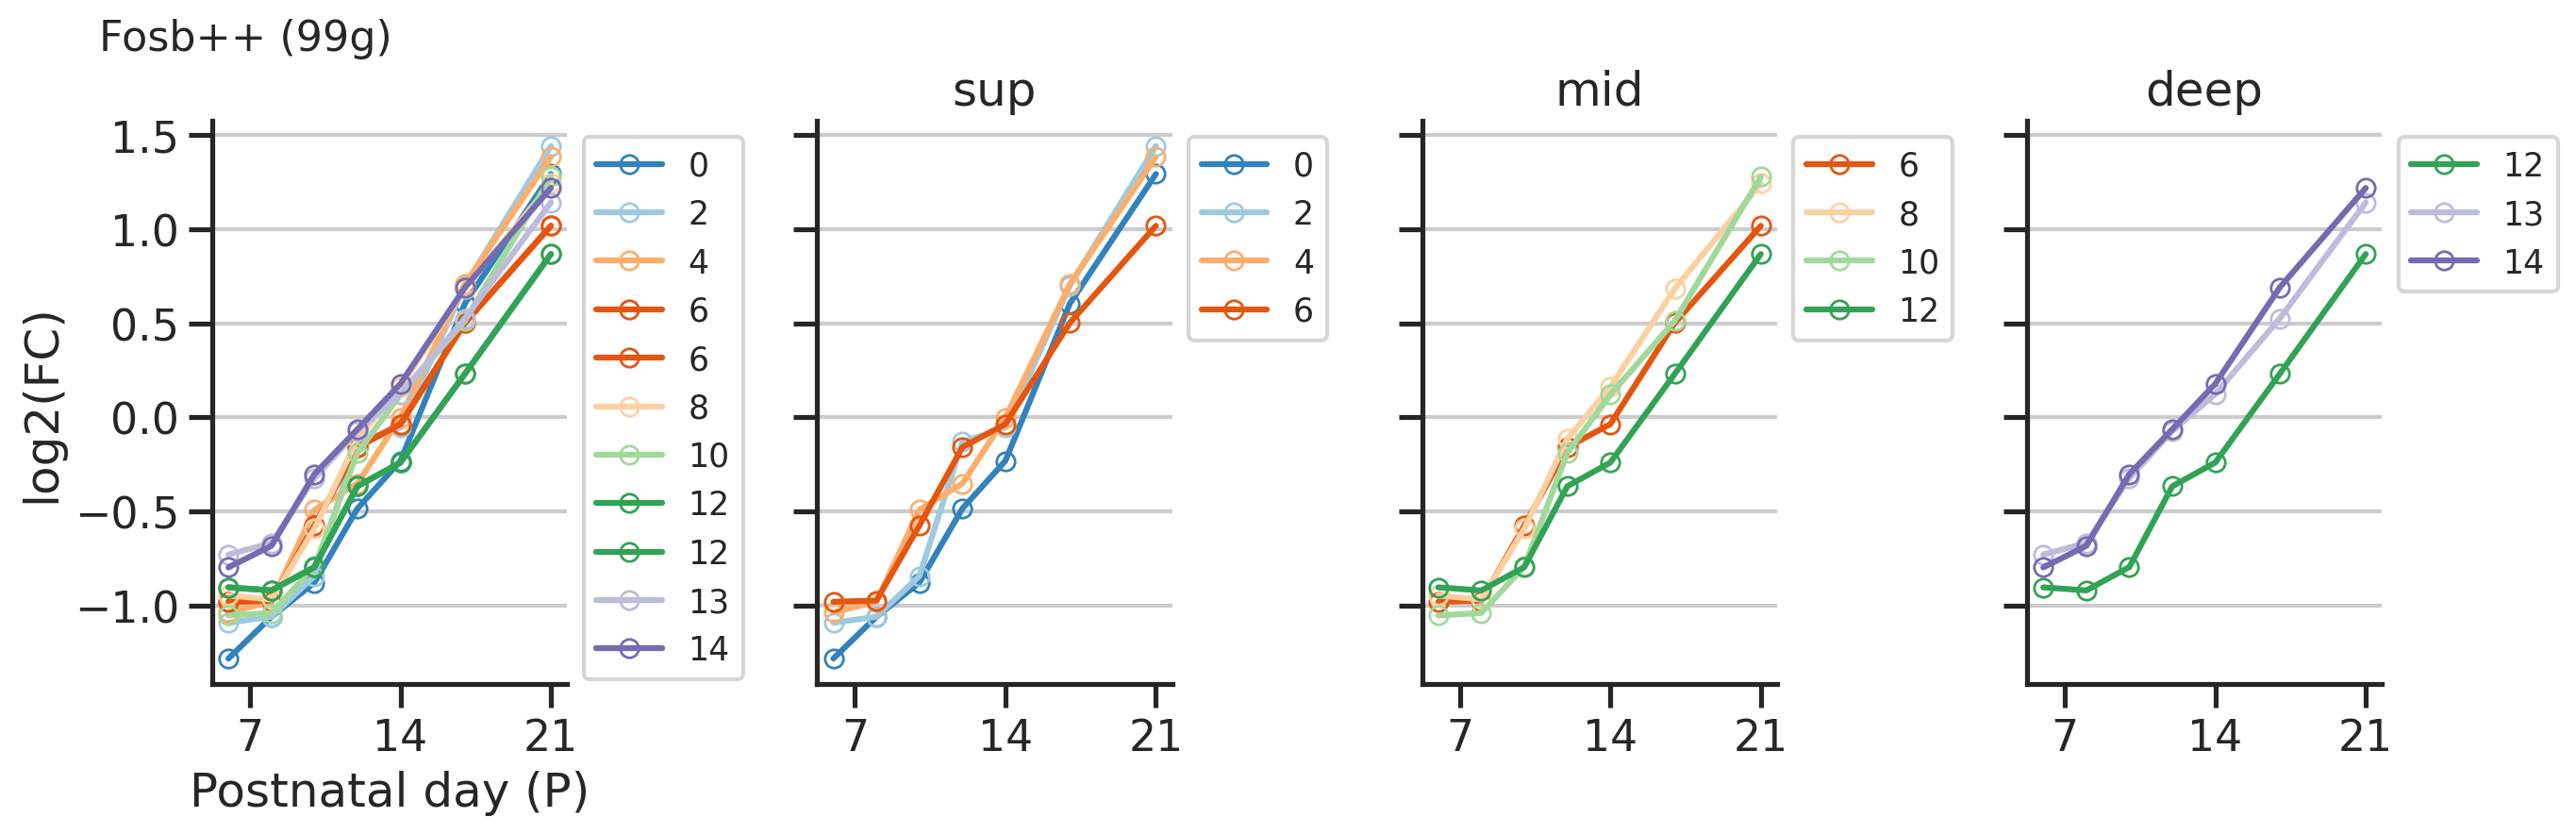

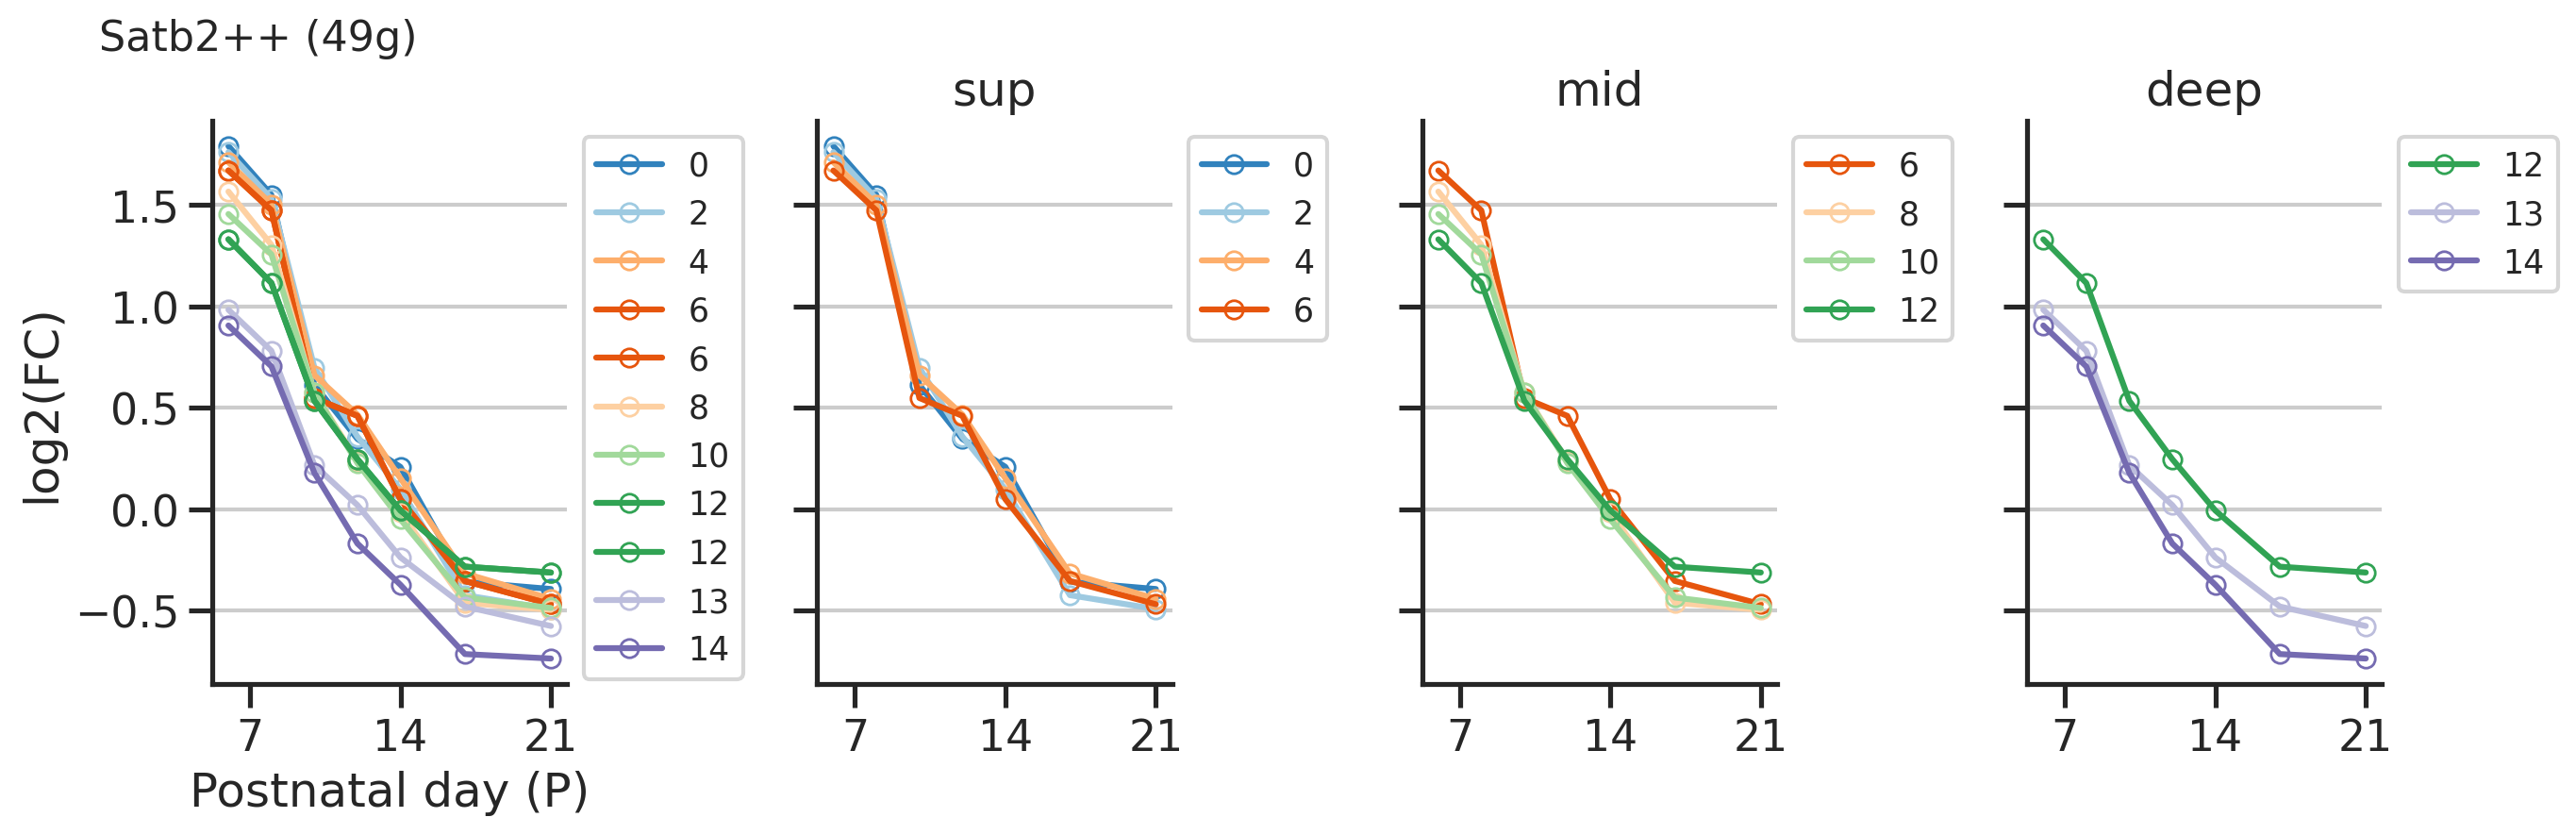

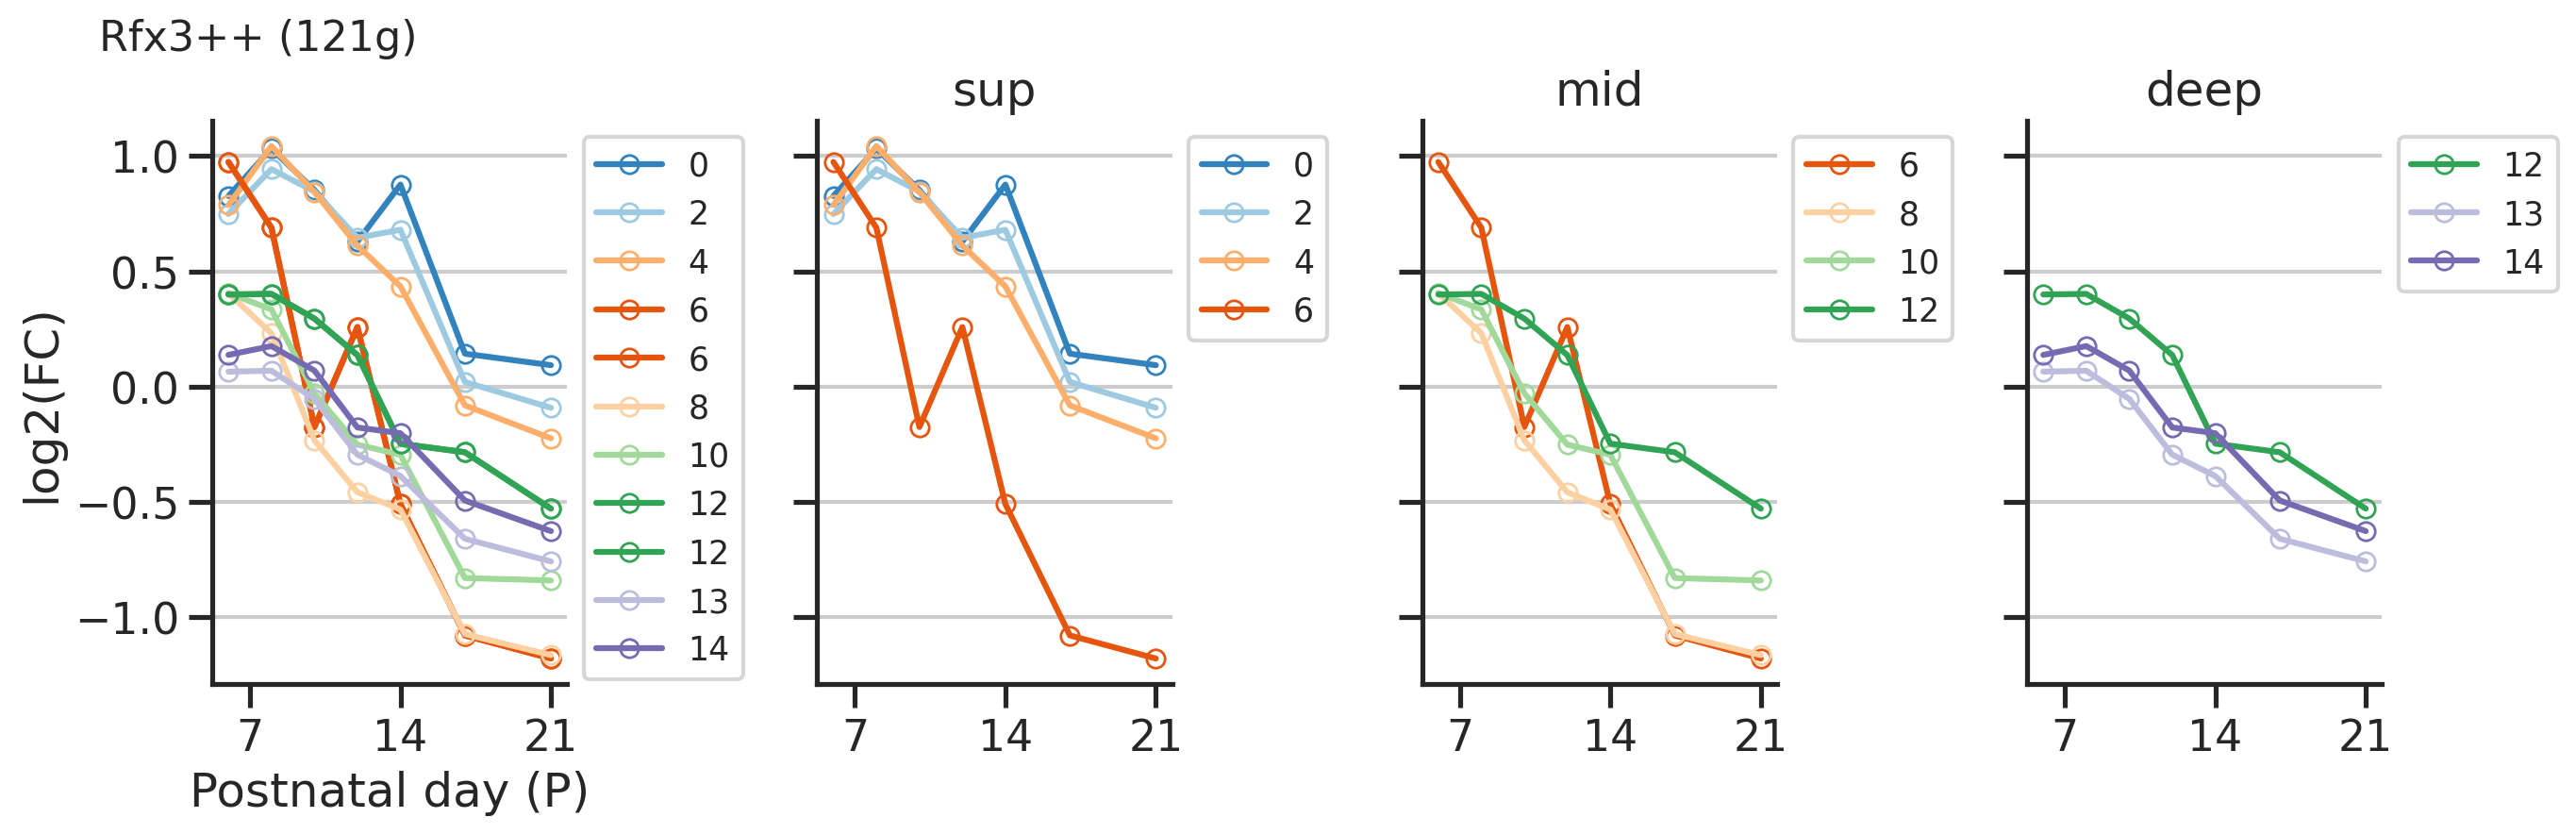

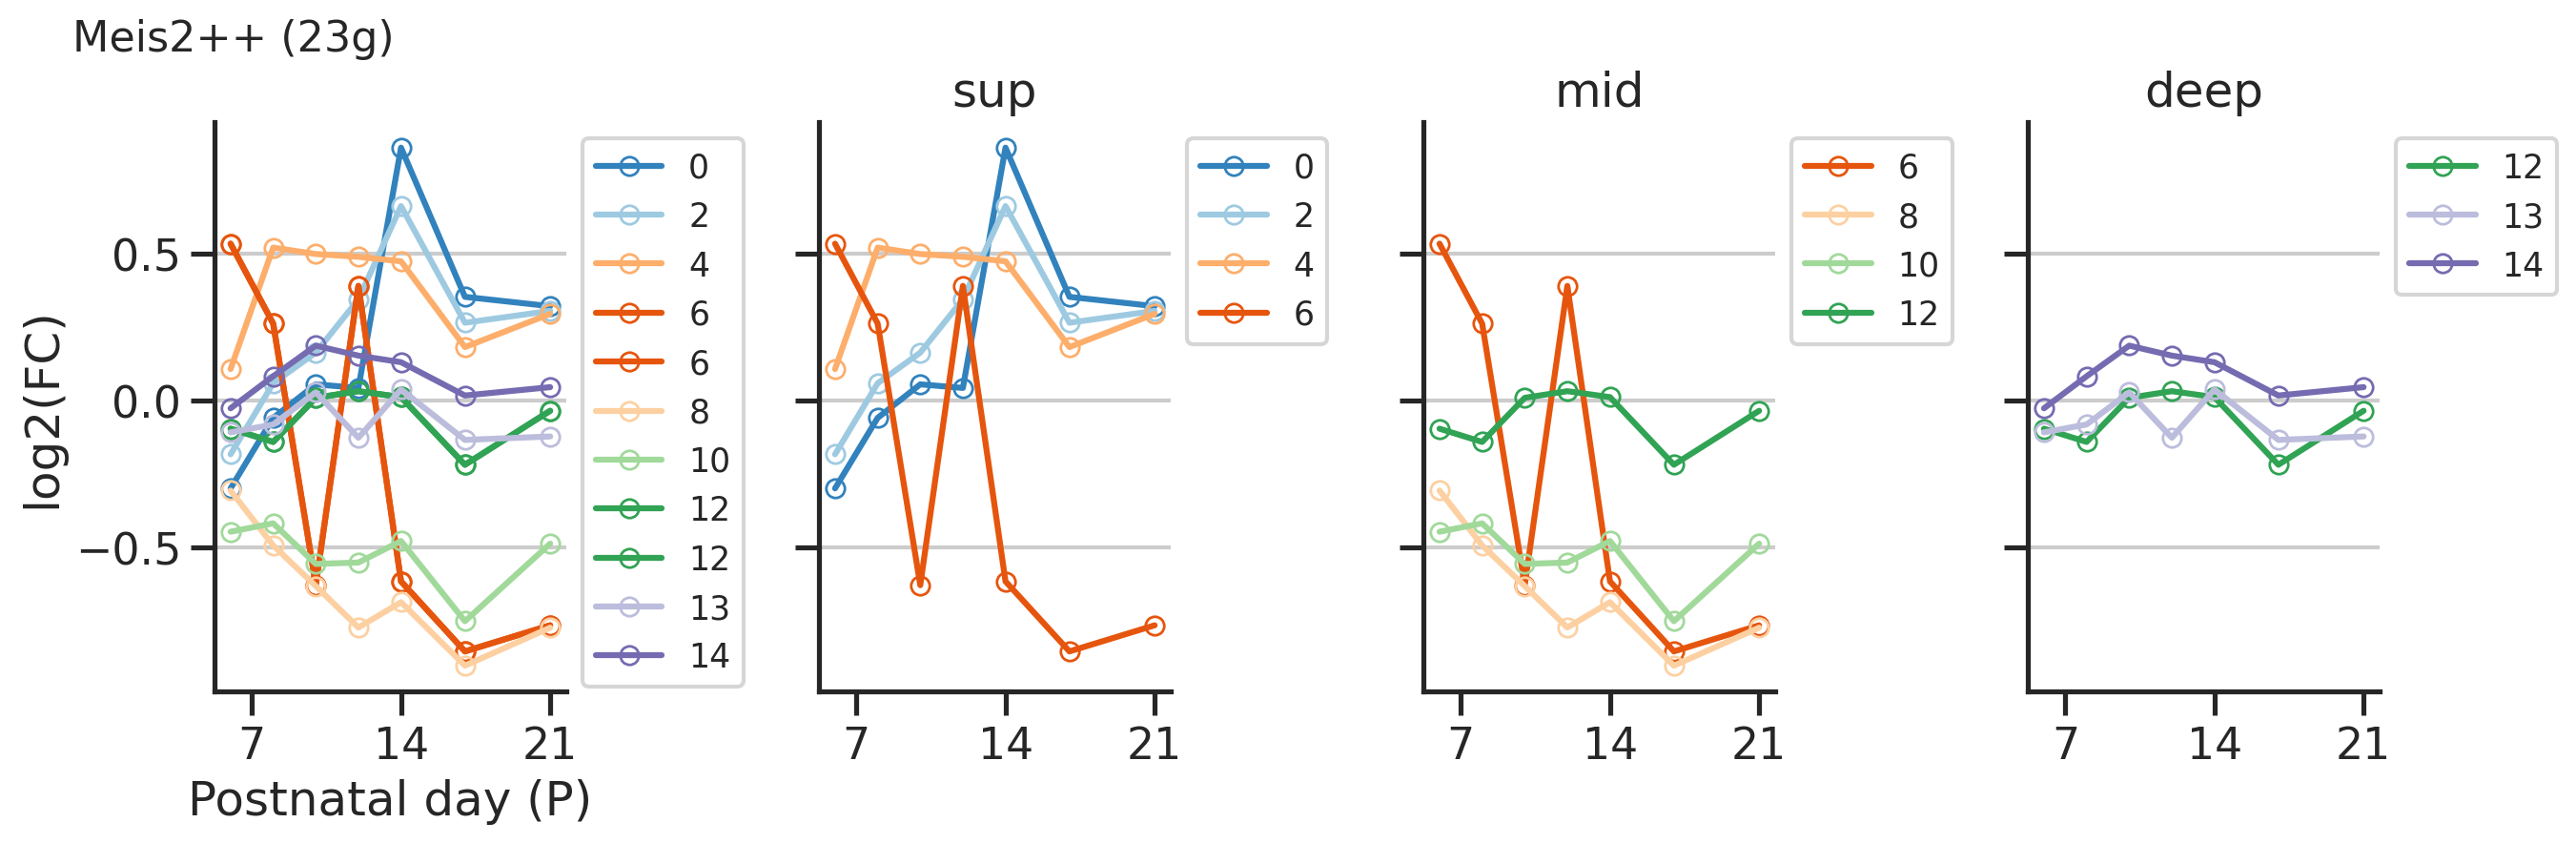

In [14]:
# plot2('Npas4++', df_scenic, baseline_gexp)
plot2('Fosb++',  df_scenic, baseline_gexp)
plot2('Satb2++', df_scenic, baseline_gexp)
plot2('Rfx3++',  df_scenic, baseline_gexp)
plot2('Meis2++', df_scenic, baseline_gexp)

# Compare two different GRNs 

In [15]:
# scenic metadata
def get_scenic(f):
    df_scenic = pd.read_csv(f, index_col=0)
    df_scenic['signs'] = df_scenic['eRegulon_name'].apply(lambda x: x[-3]+x[-1])
    df_scenic['Consensus_name'] = df_scenic['TF']+df_scenic['signs']
    df_scenic = df_scenic[df_scenic['signs'].isin(["++", "-+"])]
    
    return df_scenic

f1 = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/from_sanjana/L2_3_extended_e_regulon_metadata.csv'
f2 = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/from_sanjana/L6IT_extended_e_regulon_metadata.csv'

df_scenic1 = get_scenic(f1)
df_scenic2 = get_scenic(f2)

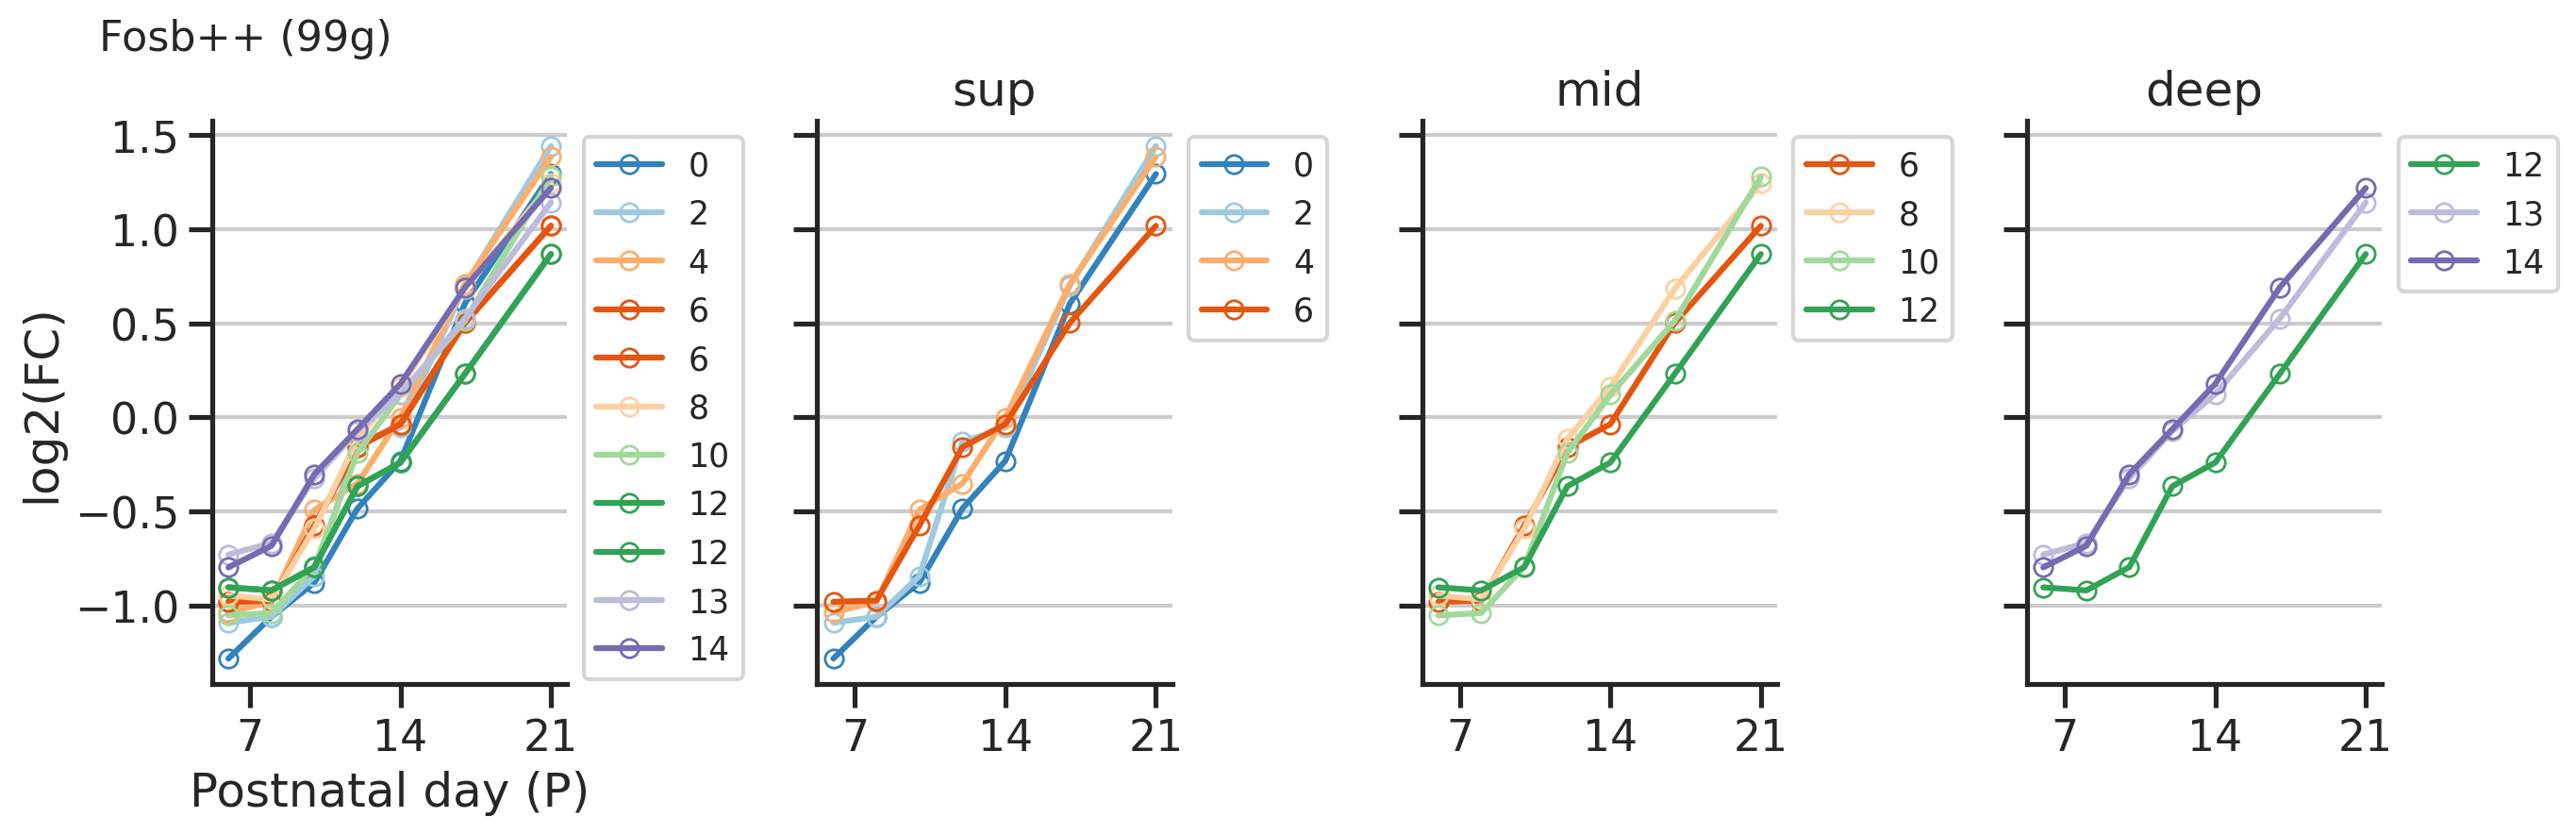

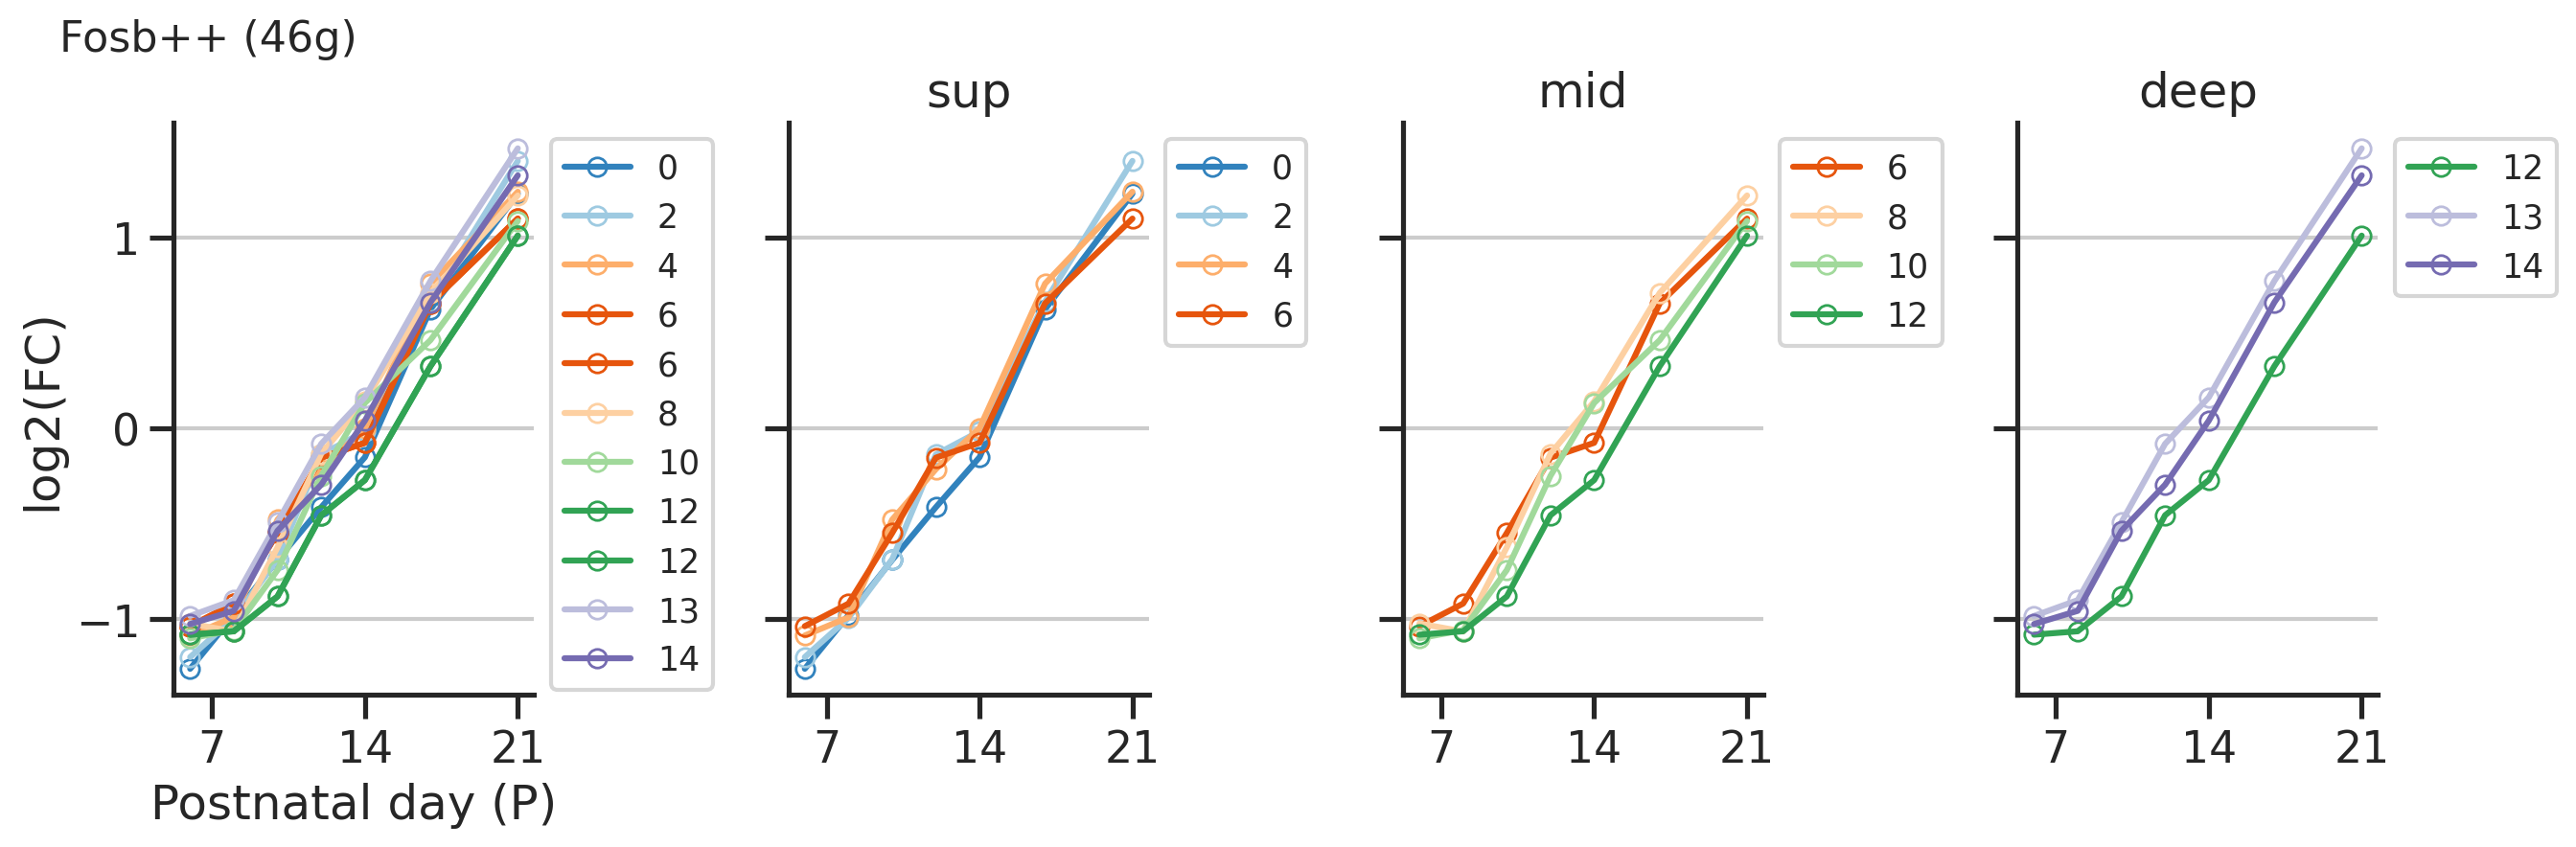

In [16]:
reg_name = 'Fosb++'
plot2(reg_name, df_scenic1, baseline_gexp)
plot2(reg_name, df_scenic2, baseline_gexp)

# Some positive gene examples (expression)

# All Activity GRNs

In [17]:
all_regulons = df_scenic1['Consensus_name'].unique()
all_regulons

array(['Aff4++', 'Arnt2++', 'Atf6++', 'Bach2++', 'Bcl11a++', 'Bclaf1++',
       'Bhlhe40++', 'Chd2++', 'Cpeb1++', 'Creb1++', 'Ctcf++', 'Cux1++',
       'Drap1++', 'E2f3++', 'Egr1++', 'Egr2++', 'Egr3++', 'Egr4++',
       'Elk3++', 'Ets1++', 'Etv1++', 'Etv5++', 'Fos++', 'Fosb++',
       'Fosl2++', 'Foxo3++', 'Hdx++', 'Hlf++', 'Ikzf2++', 'Jdp2++',
       'Junb++', 'Jund++', 'Kat7++', 'Klf10++', 'Klf12++', 'Klf13++',
       'Klf8++', 'Klf9++', 'Lcorl++', 'Max++', 'Mbd2++', 'Mbnl2++',
       'Mecp2++', 'Mef2c++', 'Mef2d++', 'Meis2++', 'Mta3++', 'Mxi1++',
       'Nfia++', 'Nfib++', 'Nfyc++', 'Nr2c2++', 'Nr3c1++', 'Nrf1++',
       'Olig1++', 'Pbx1++', 'Plag1++', 'Pou3f1++', 'Pou3f2++', 'Pura++',
       'Rbpj++', 'Rcor1++', 'Rfx3++', 'Rora++', 'Satb1++', 'Satb2++',
       'Sin3a++', 'Smad3++', 'Sox10++', 'Sox5++', 'Sp3++', 'Sp7++',
       'Taf1++', 'Tcf12++', 'Tcf4++', 'Tef++', 'Tfdp1++', 'Tfdp2++',
       'Thra++', 'Thrb++', 'Zbtb11++', 'Zbtb18++', 'Zbtb20++', 'Zbtb7a++',
       'Zeb1++', 'Zf

In [20]:
arg_regulons = [
    'Nr3c1++',
    'Fos++', 'Fosb++', 'Fosl2++', 
    'Junb++', 'Jund++', 
    'Egr1++', 'Egr2++', 'Egr3++', 'Egr4++',]

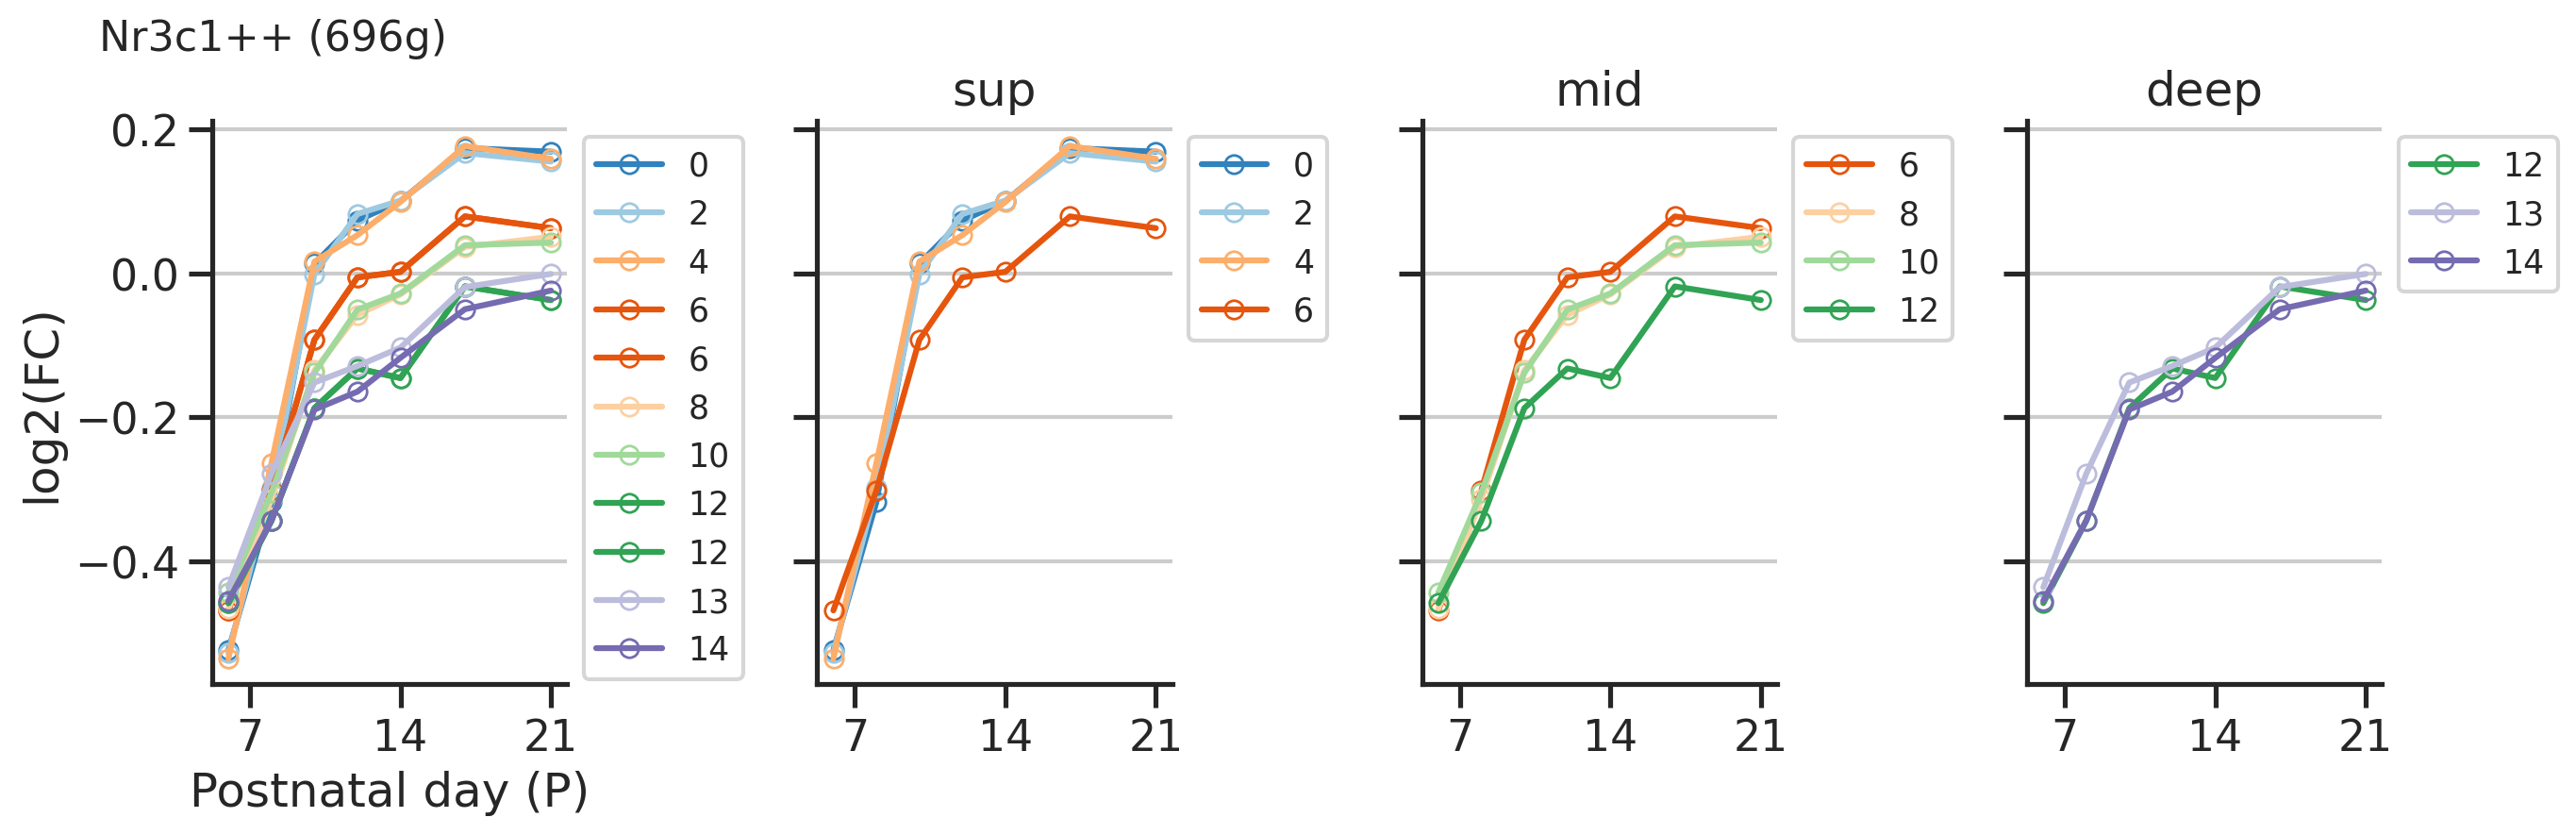

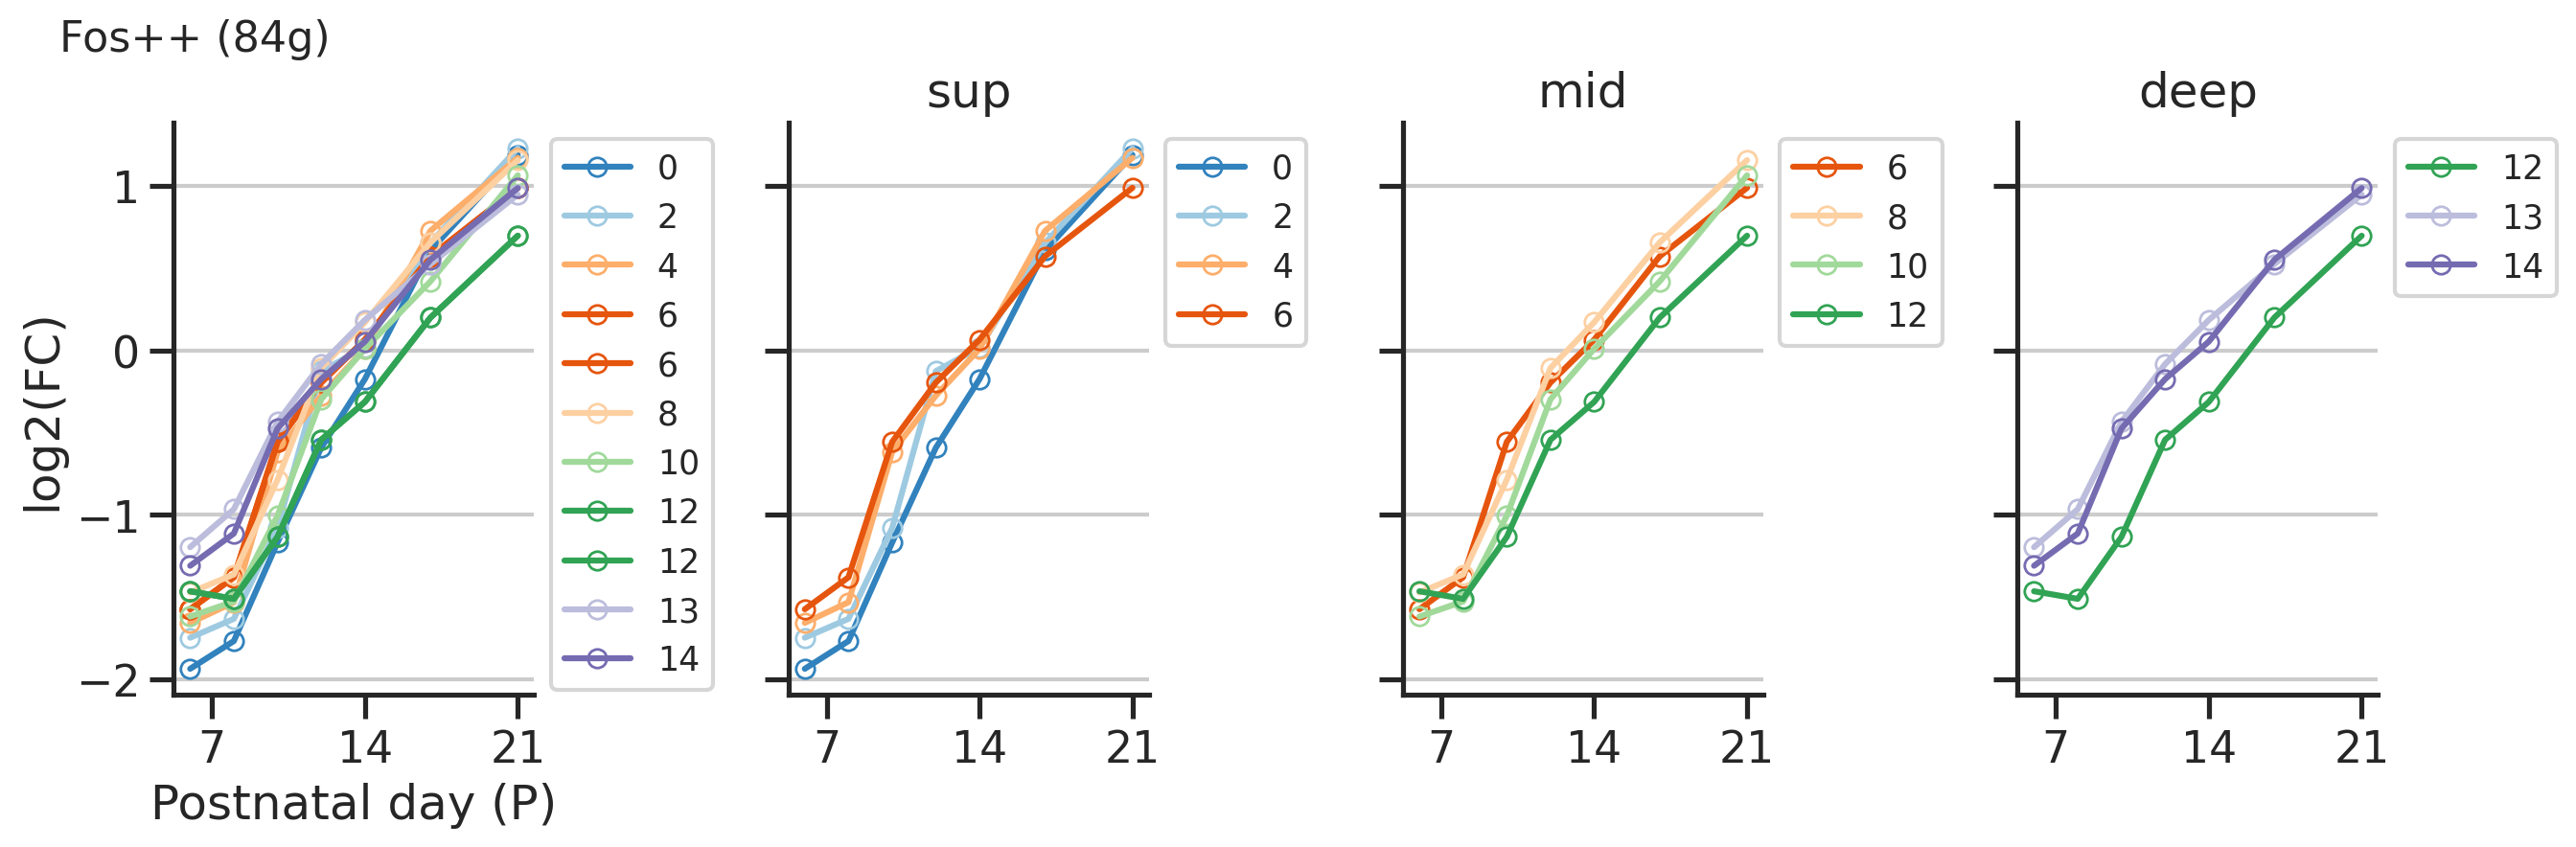

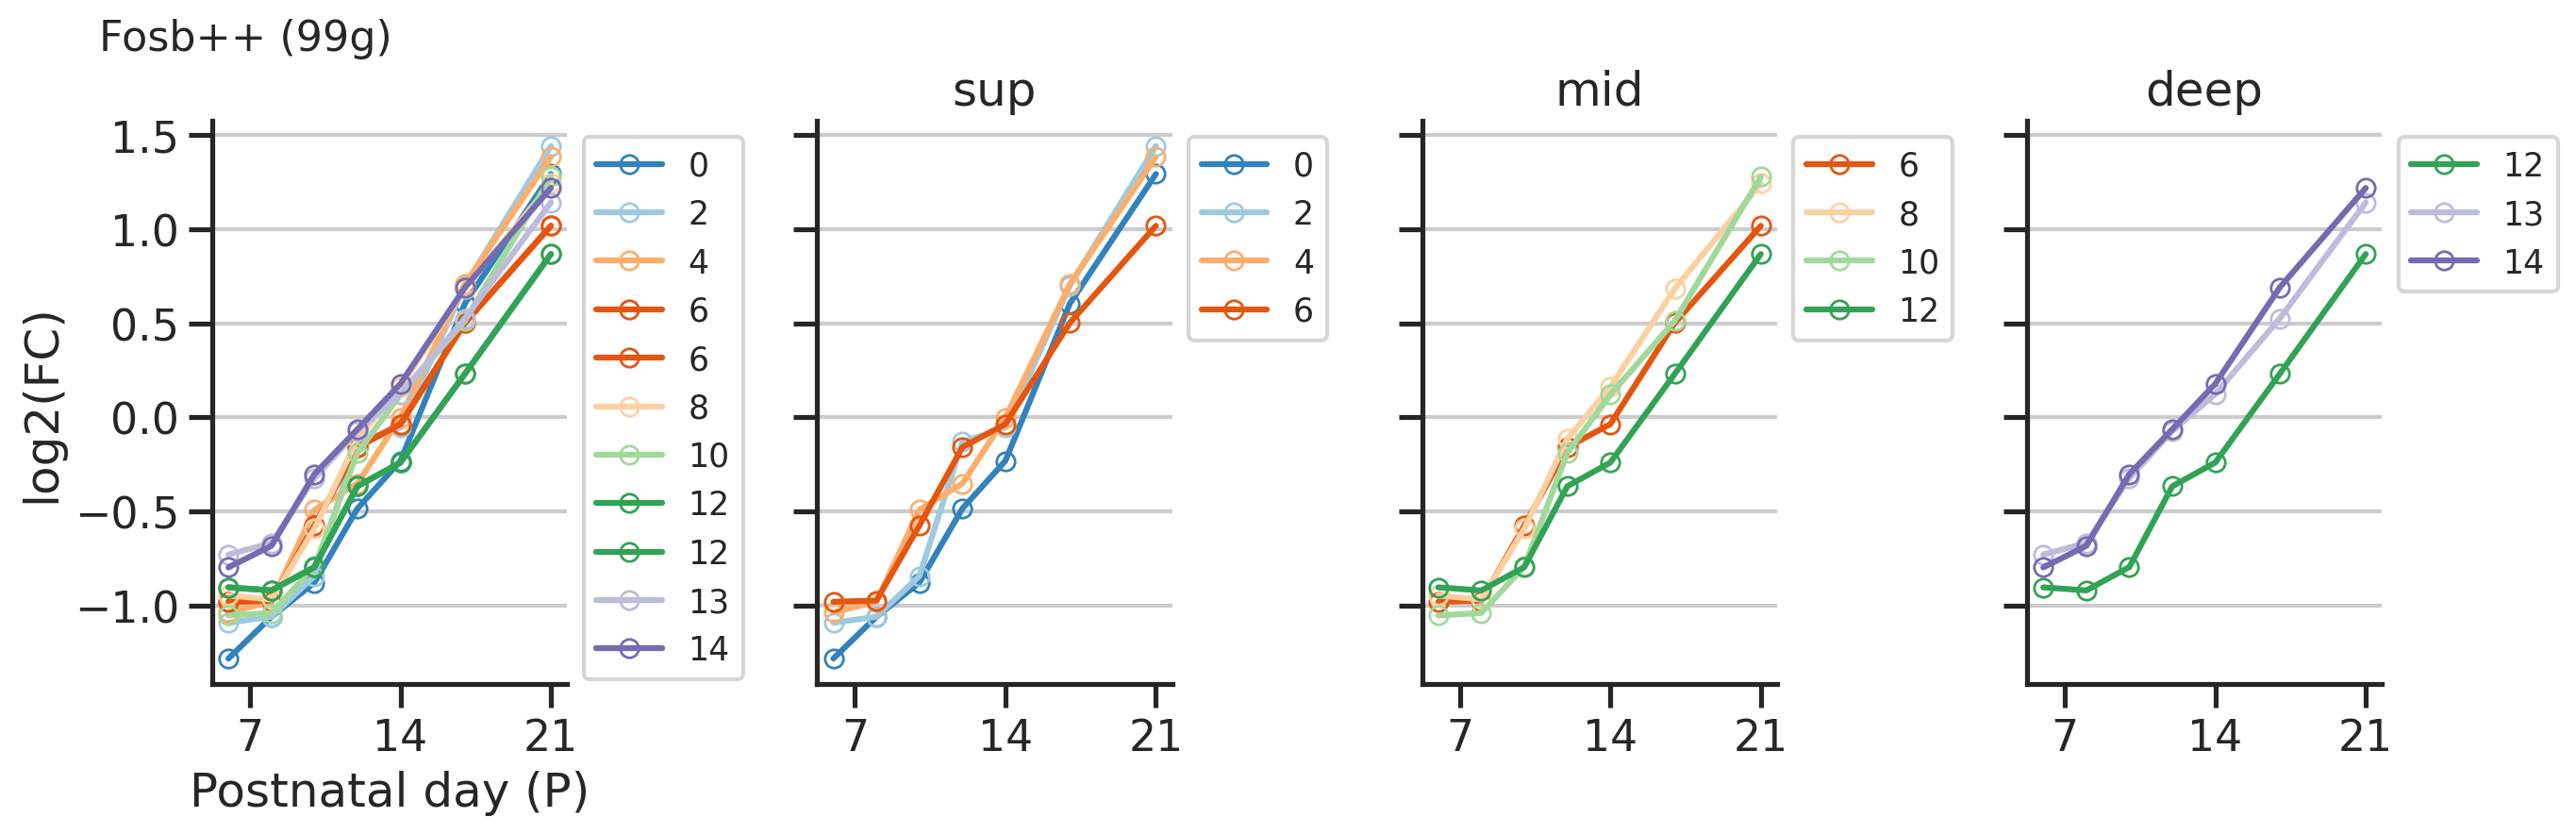

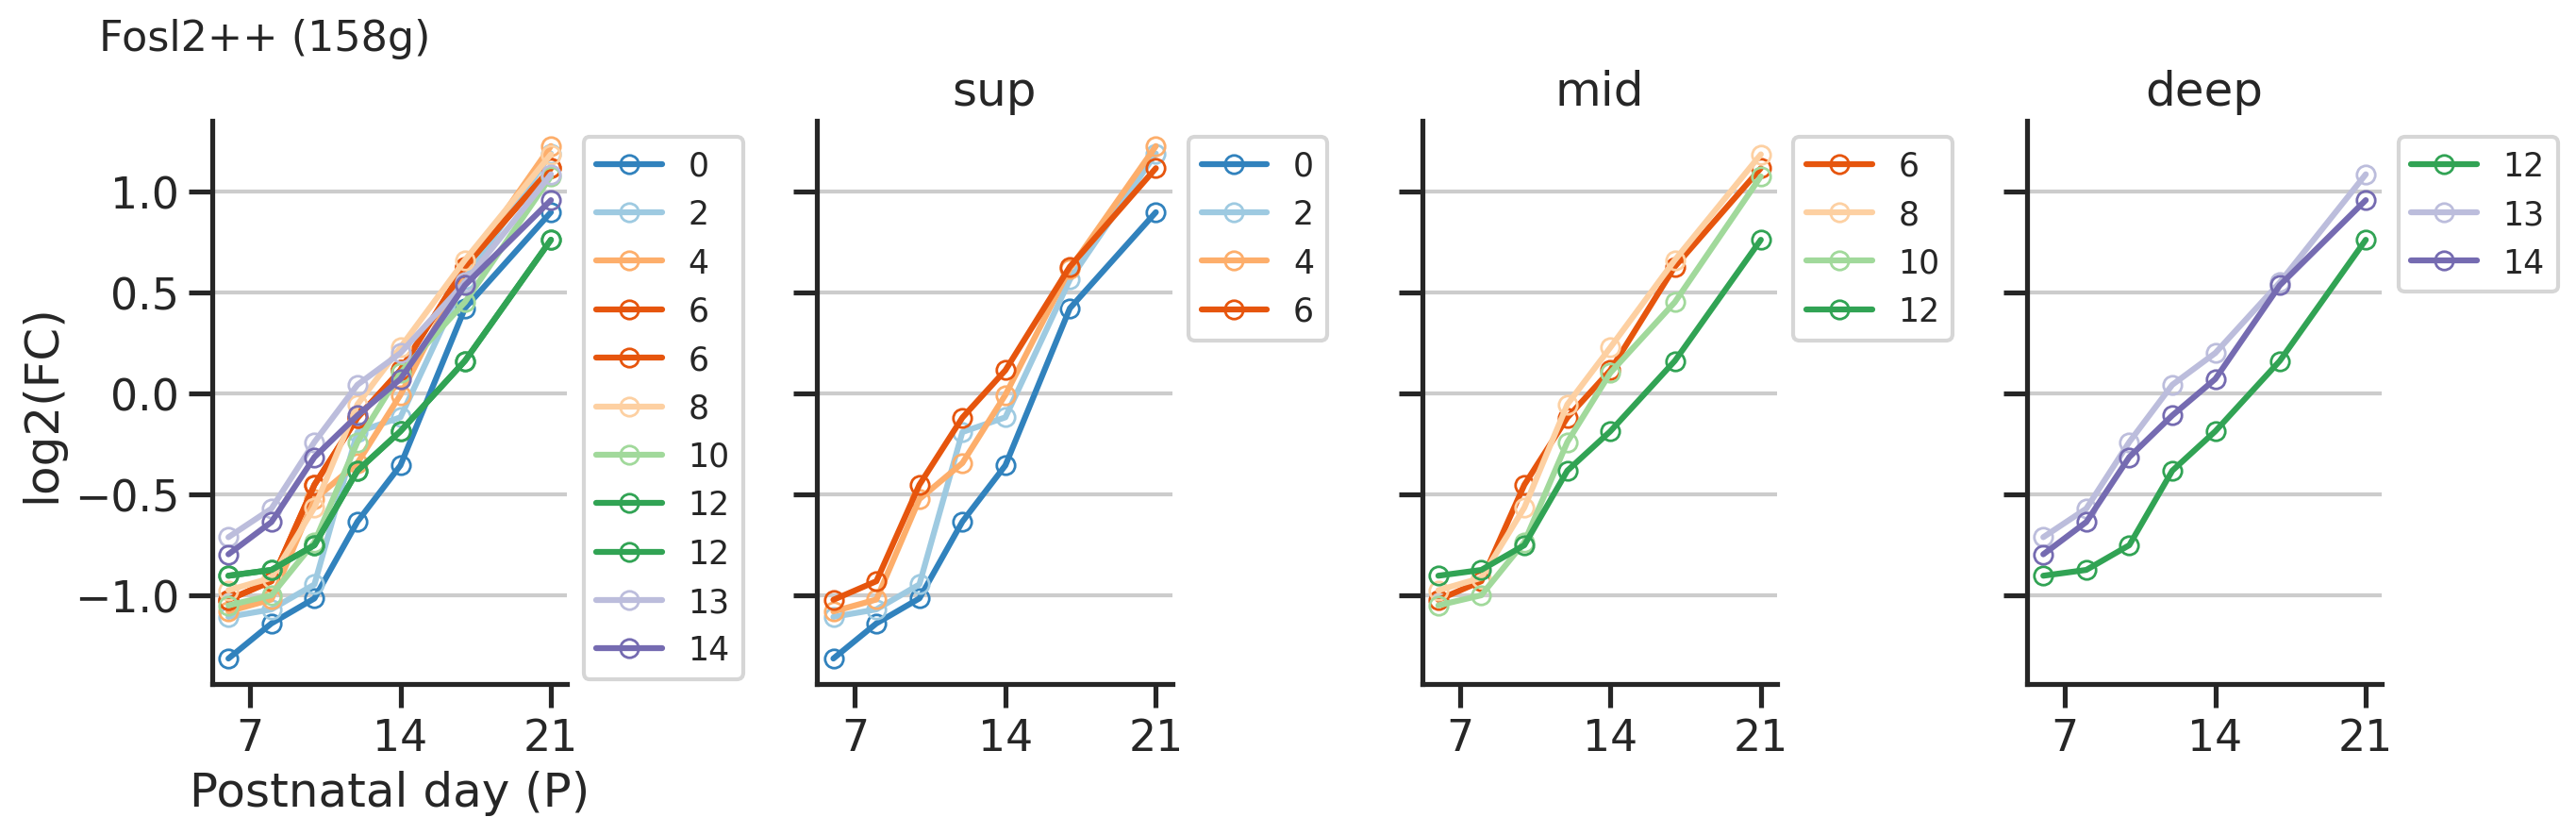

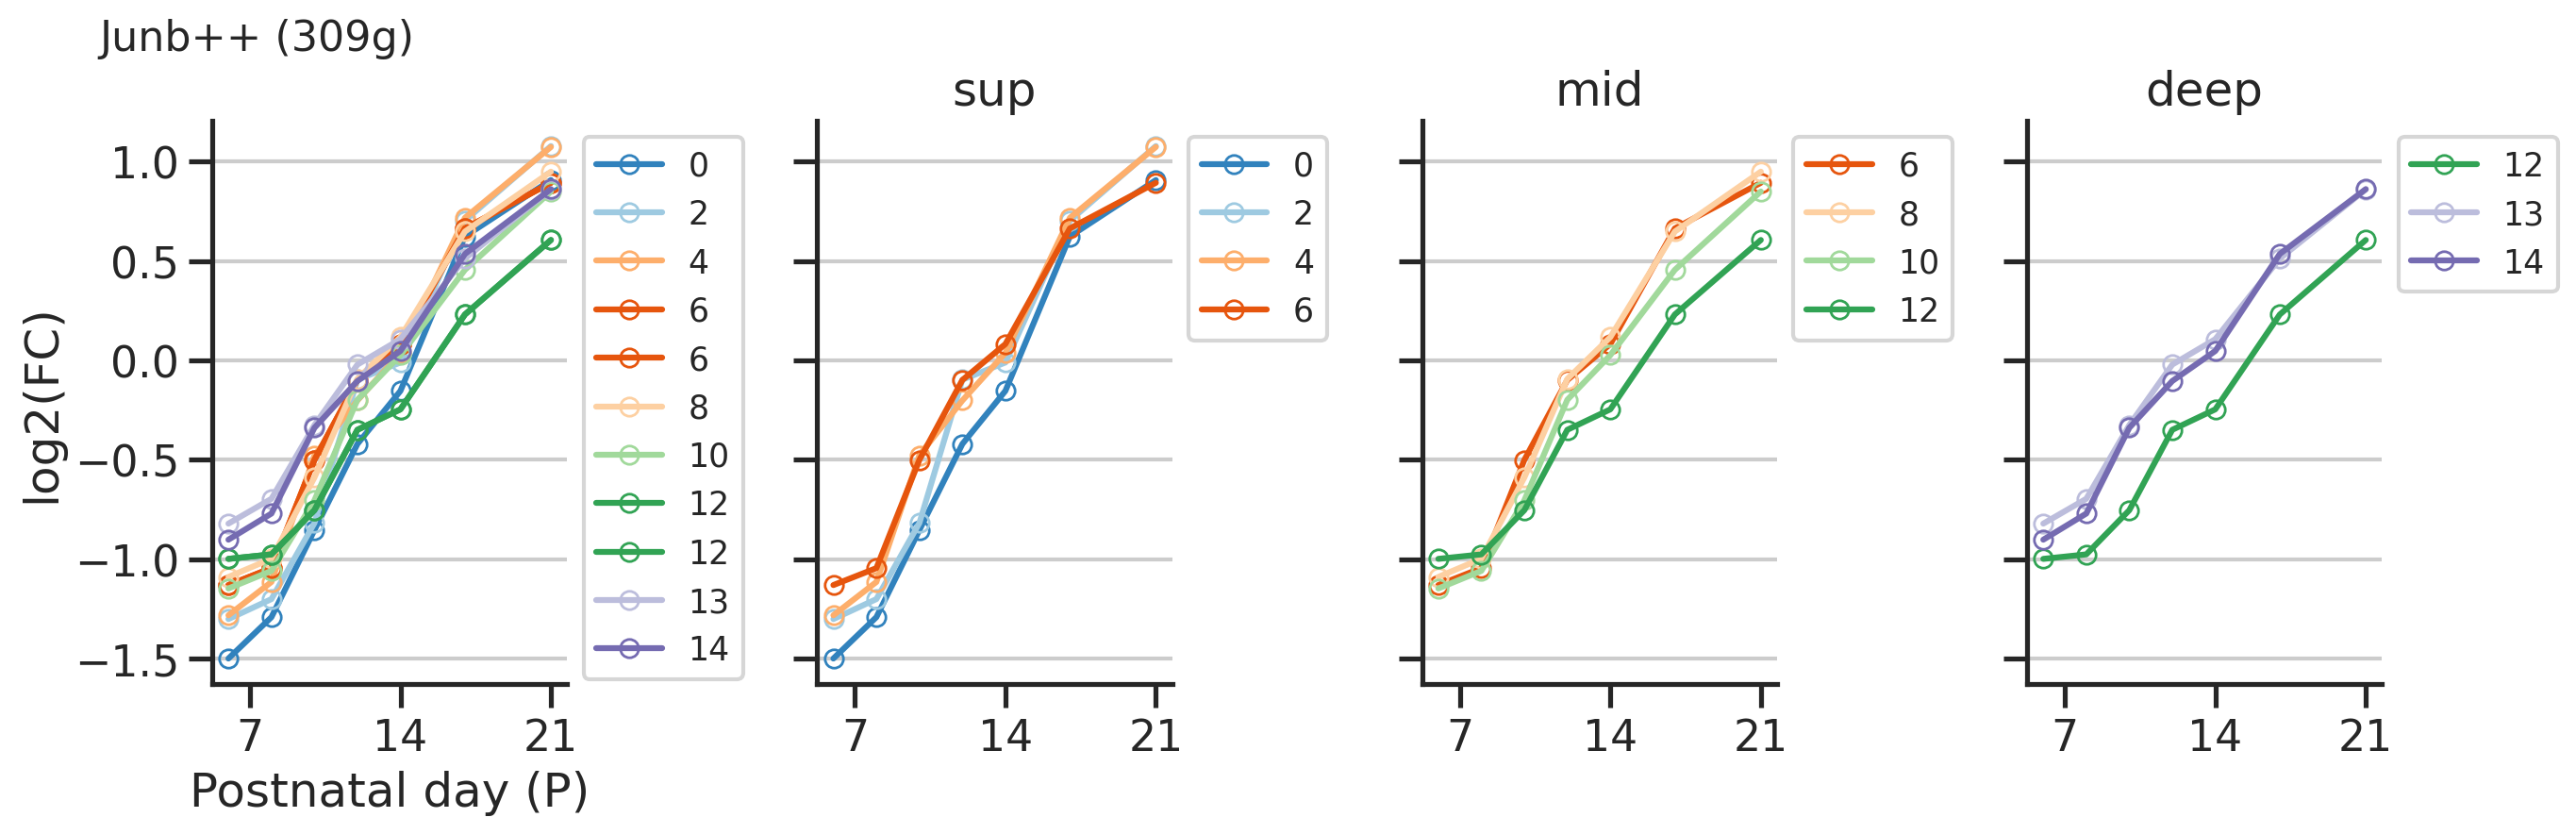

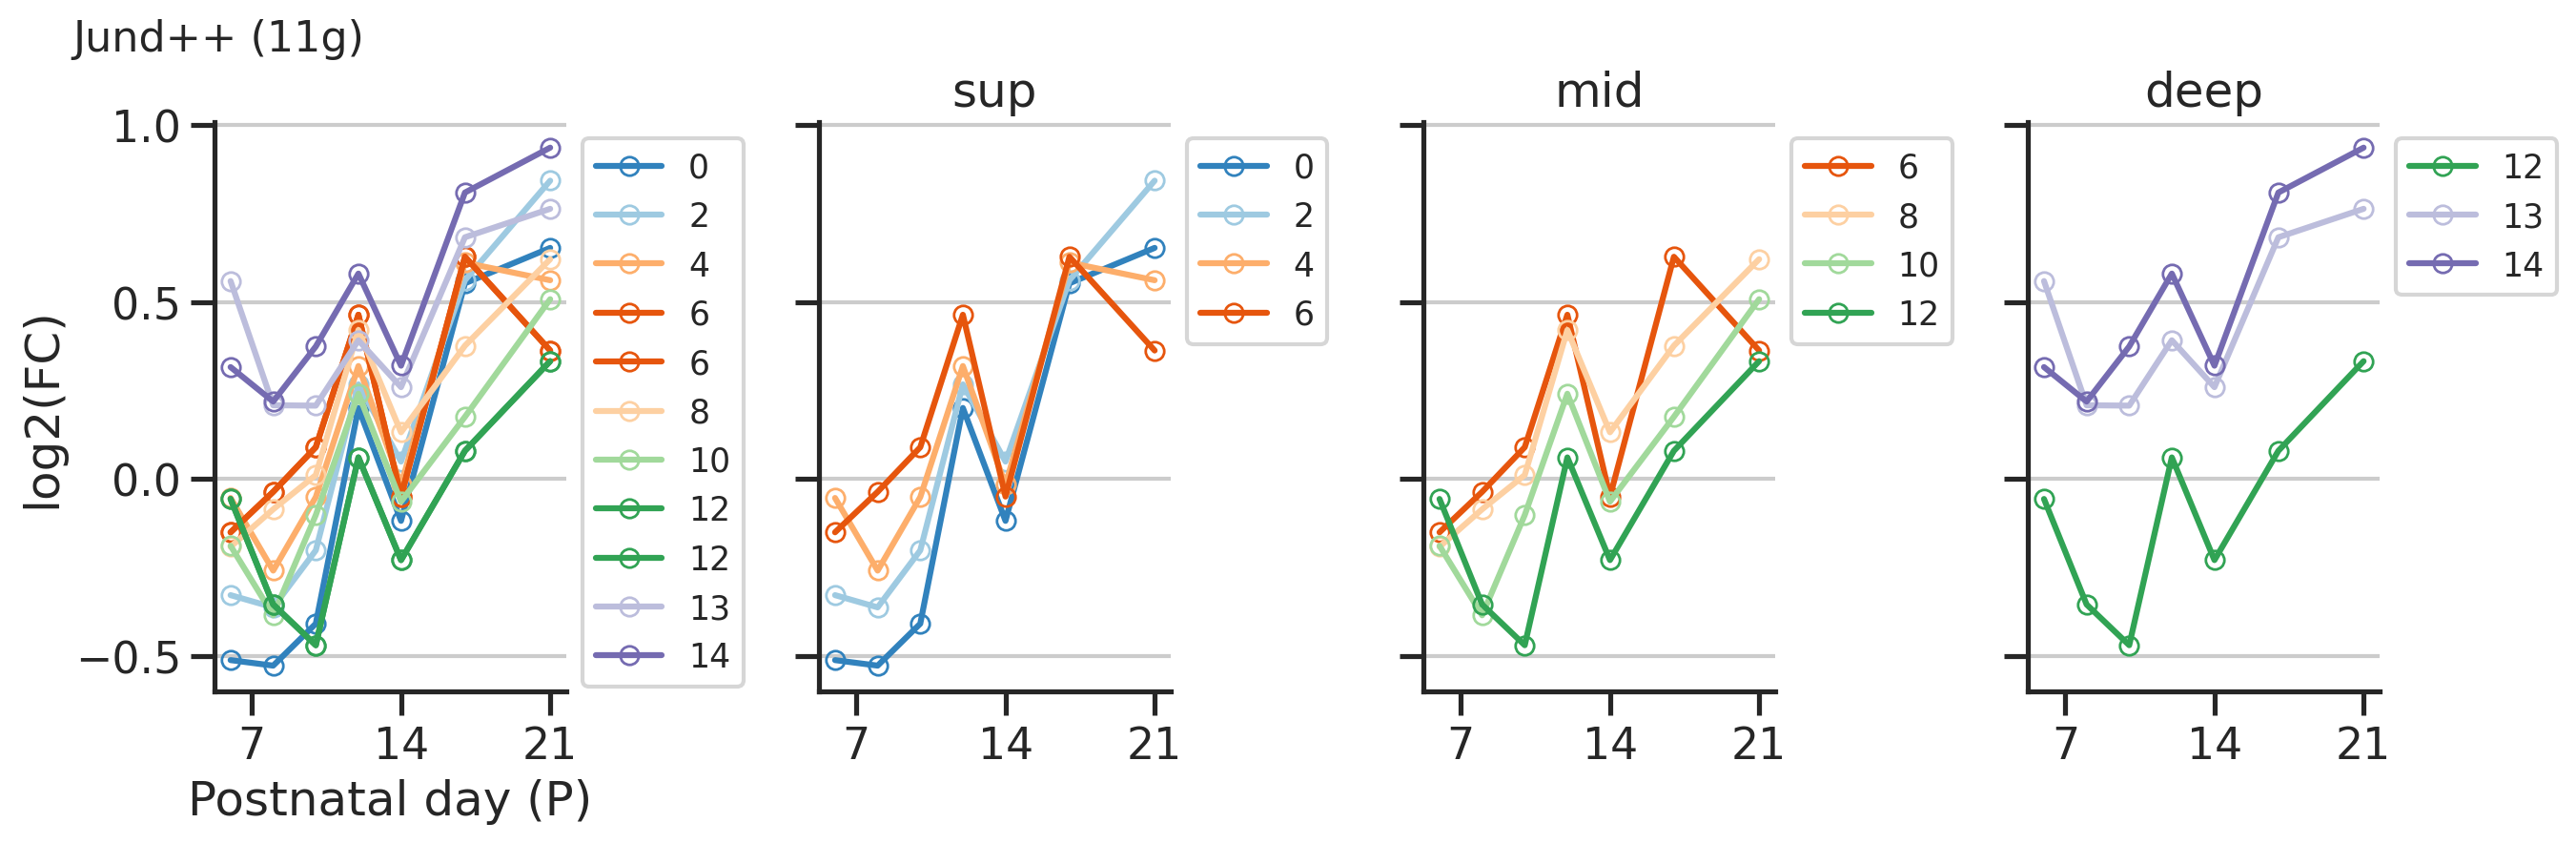

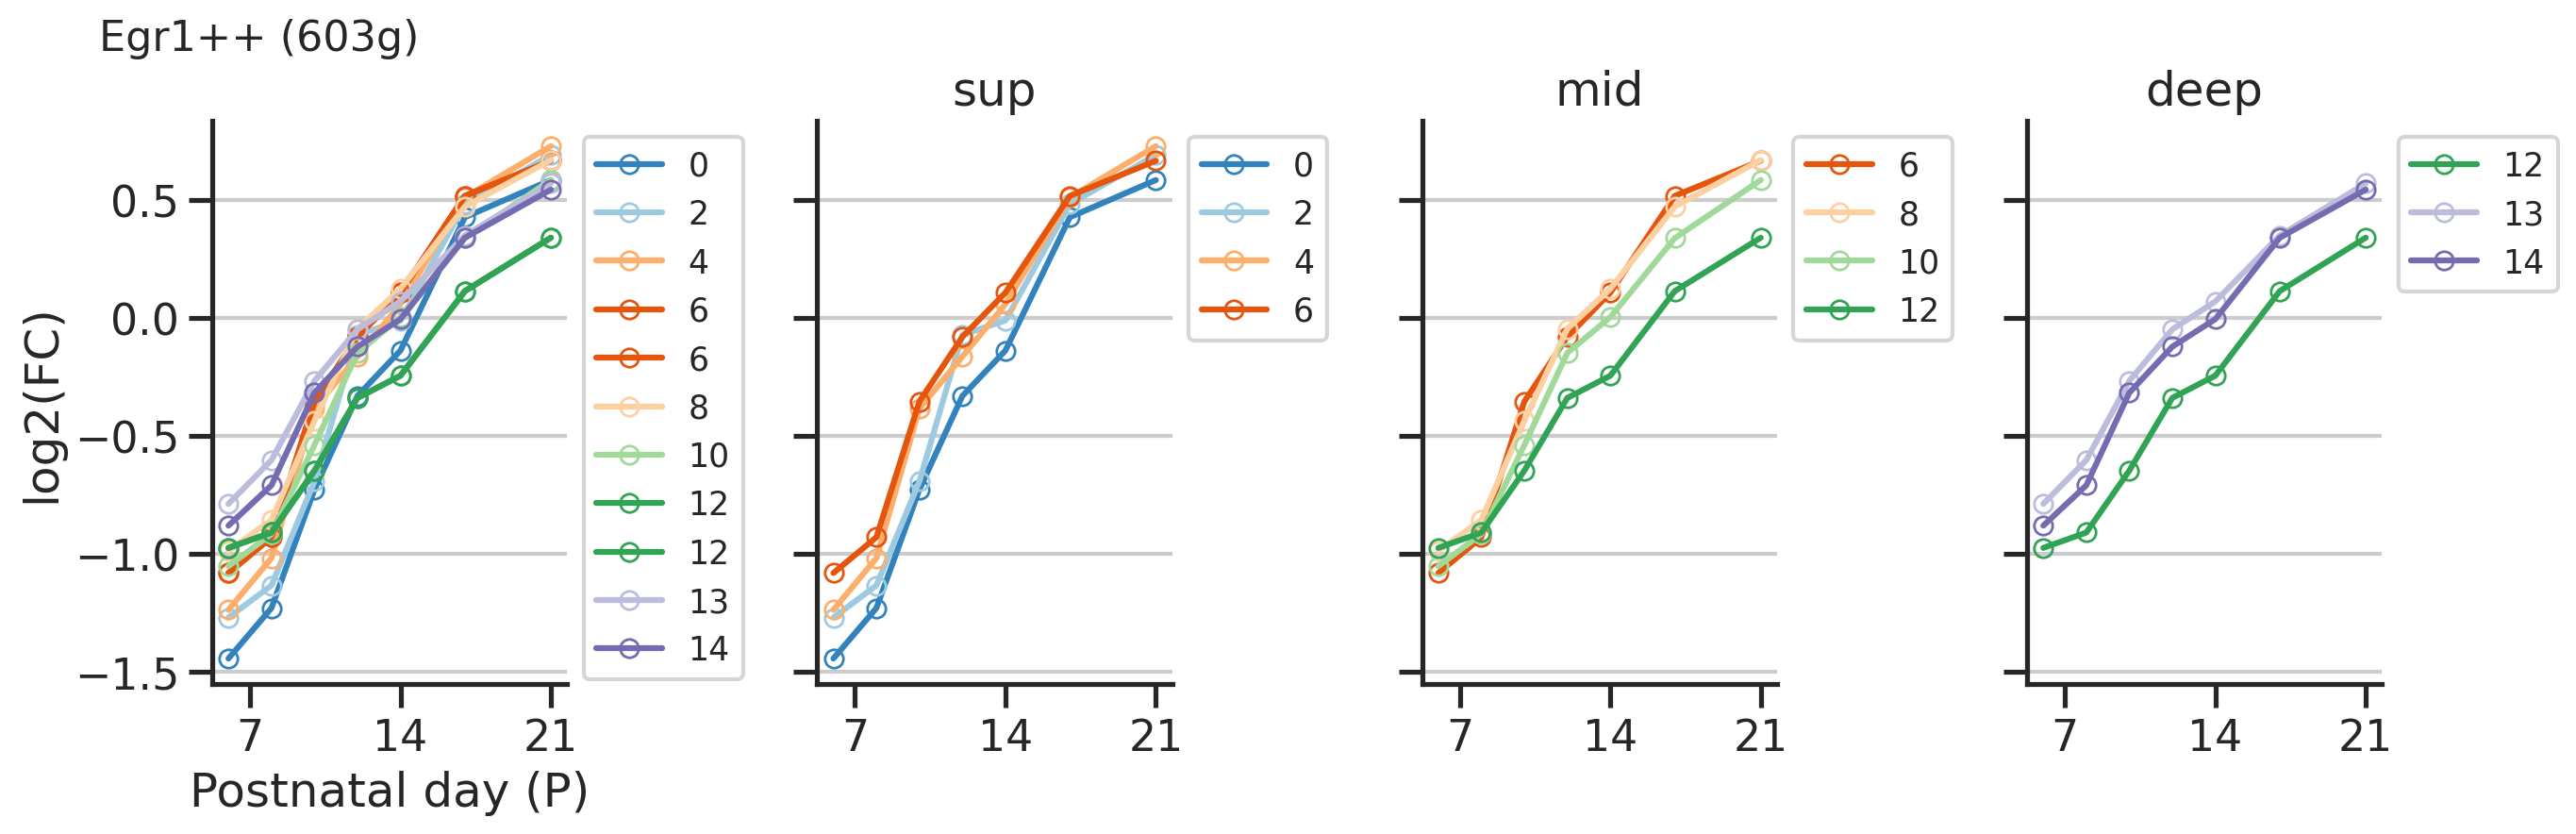

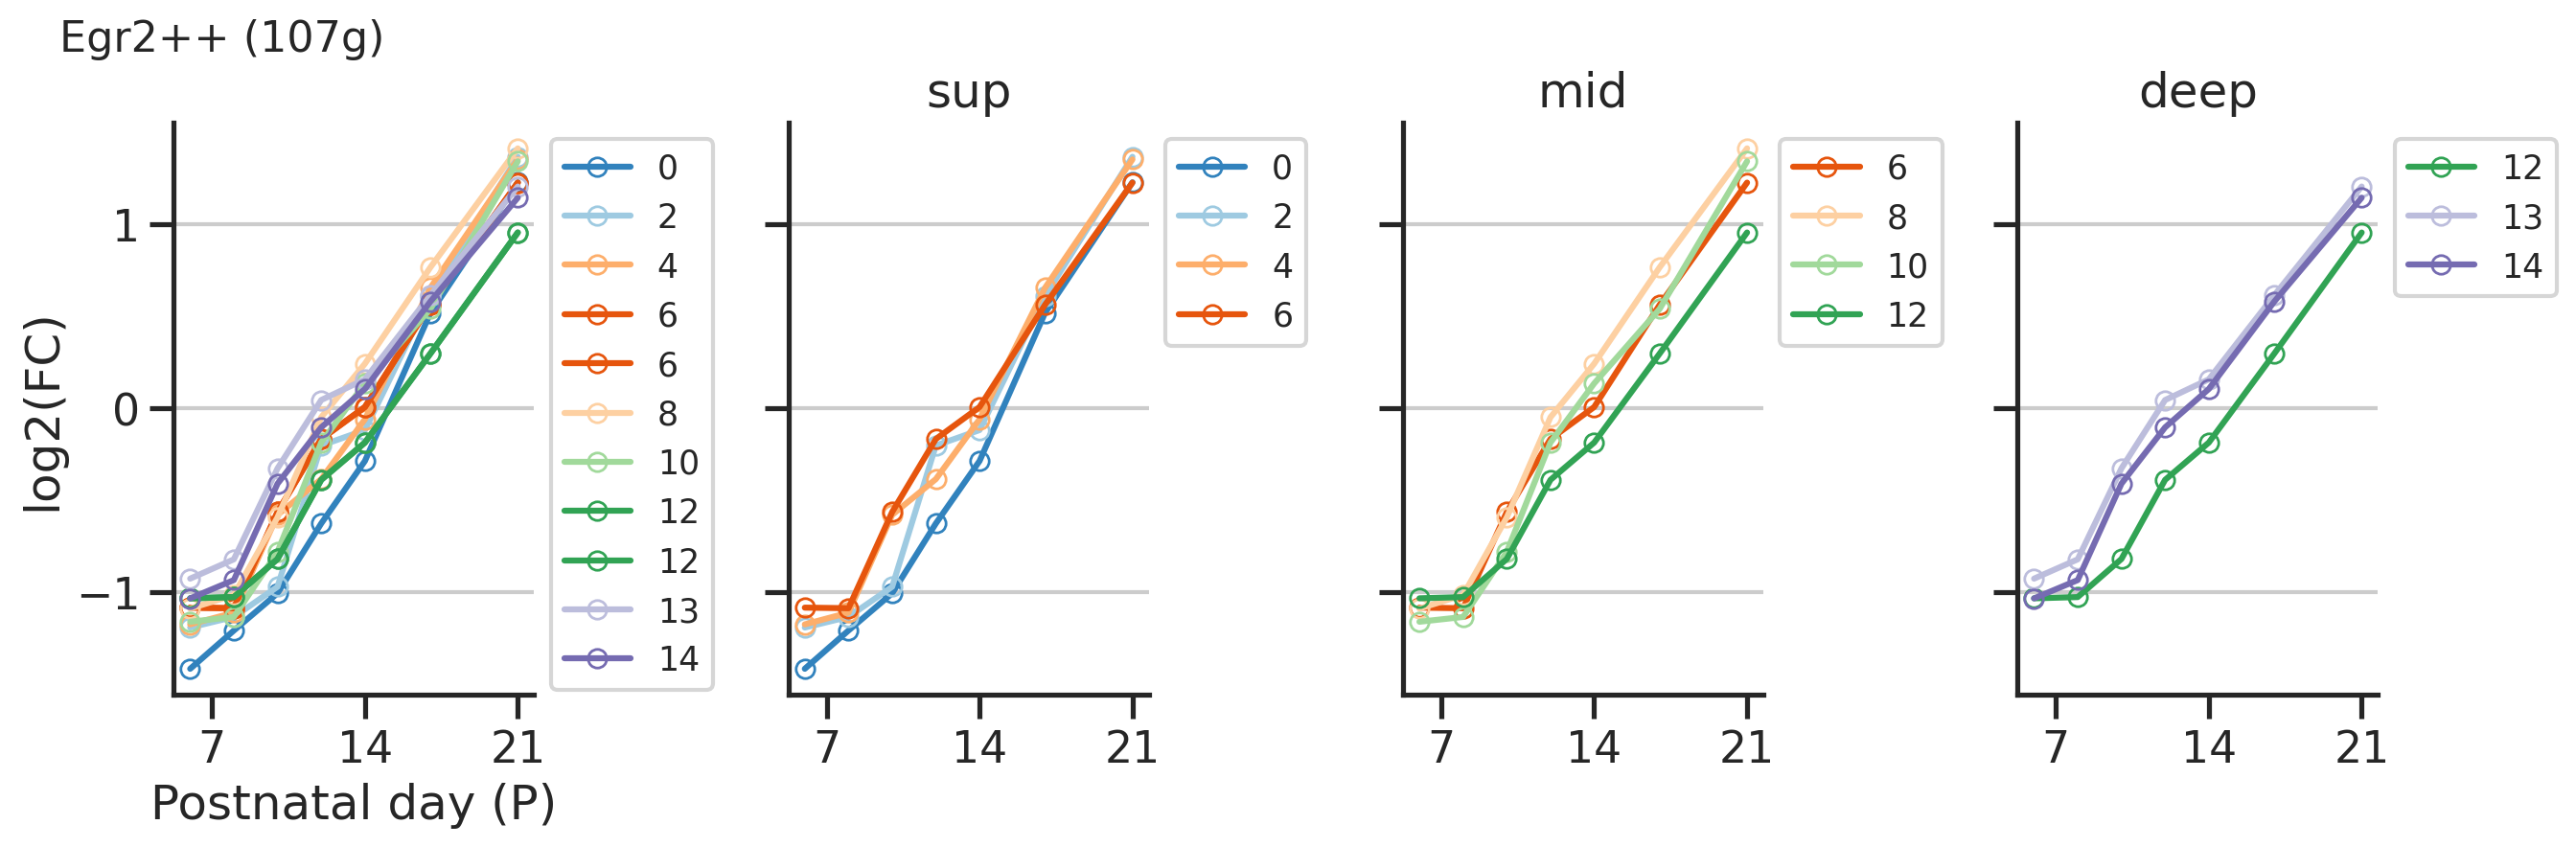

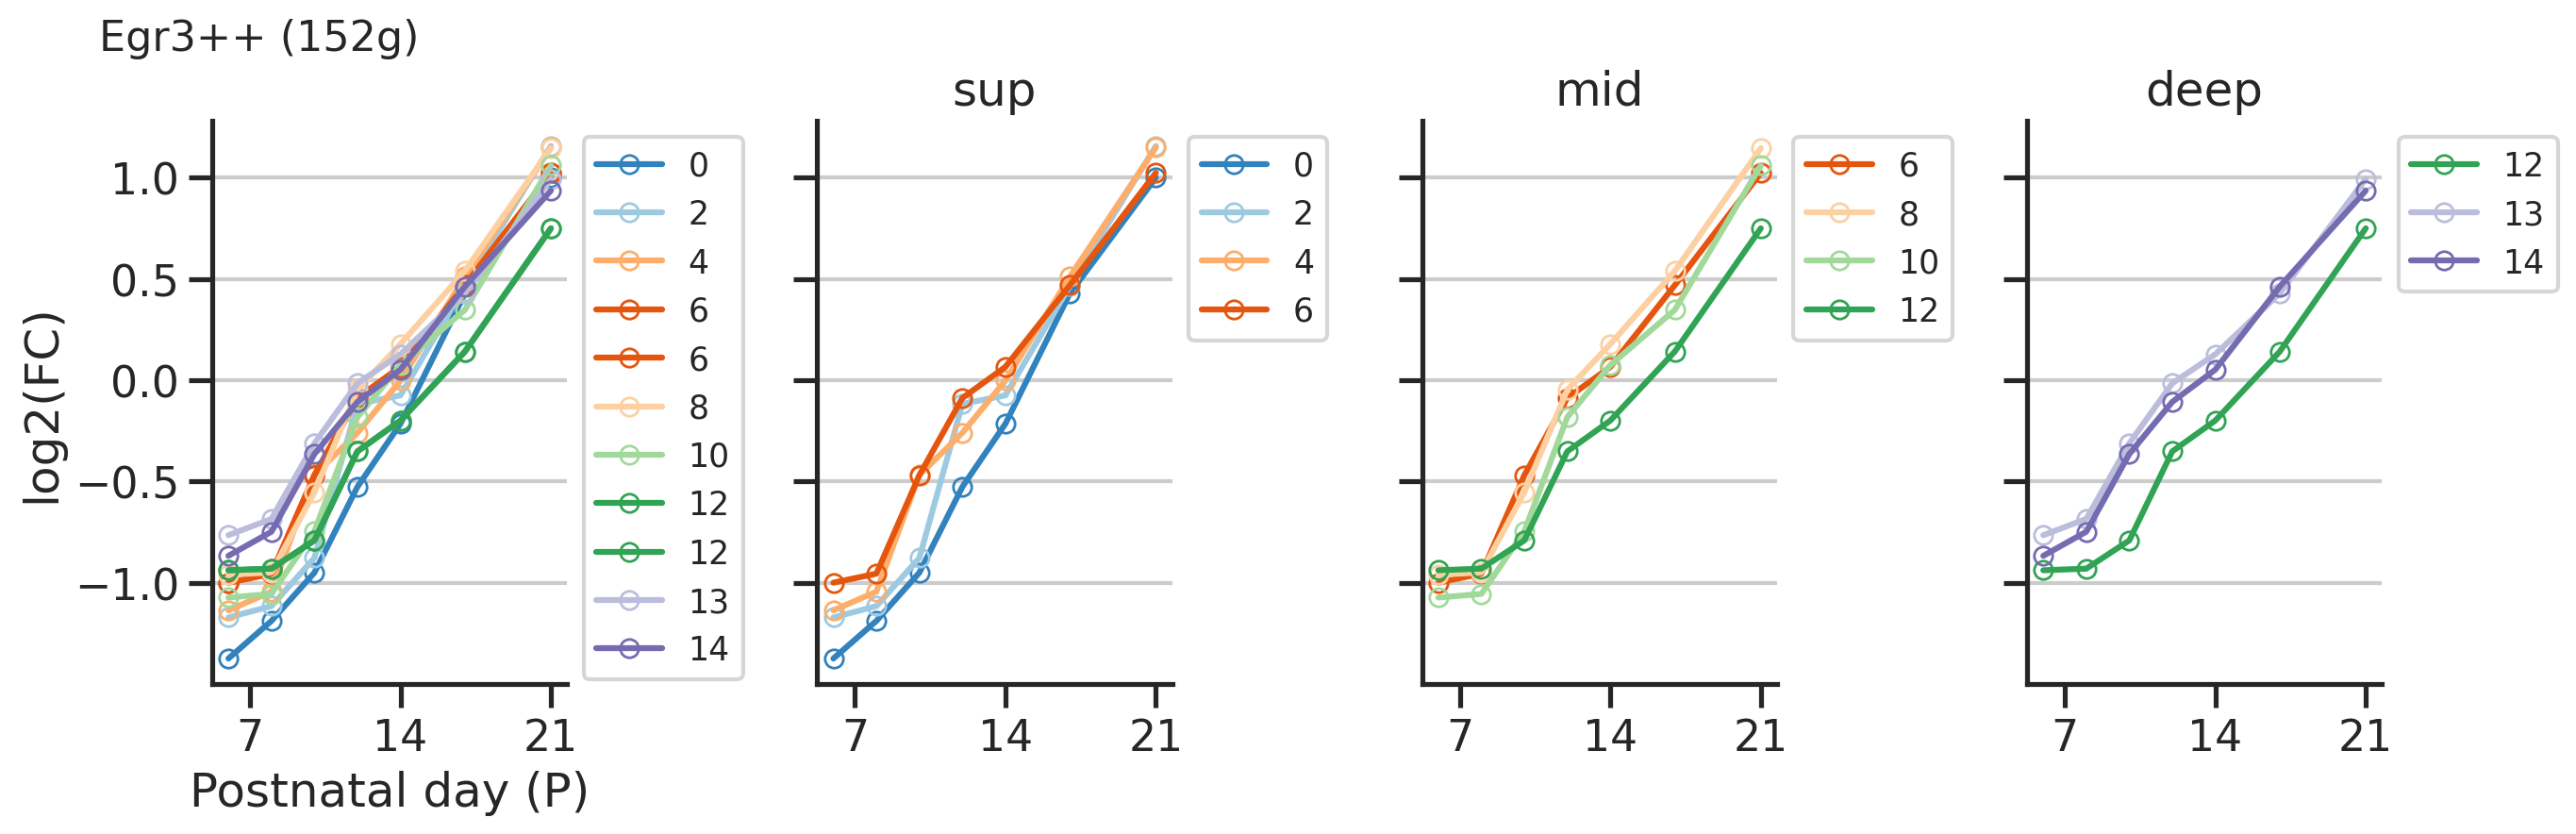

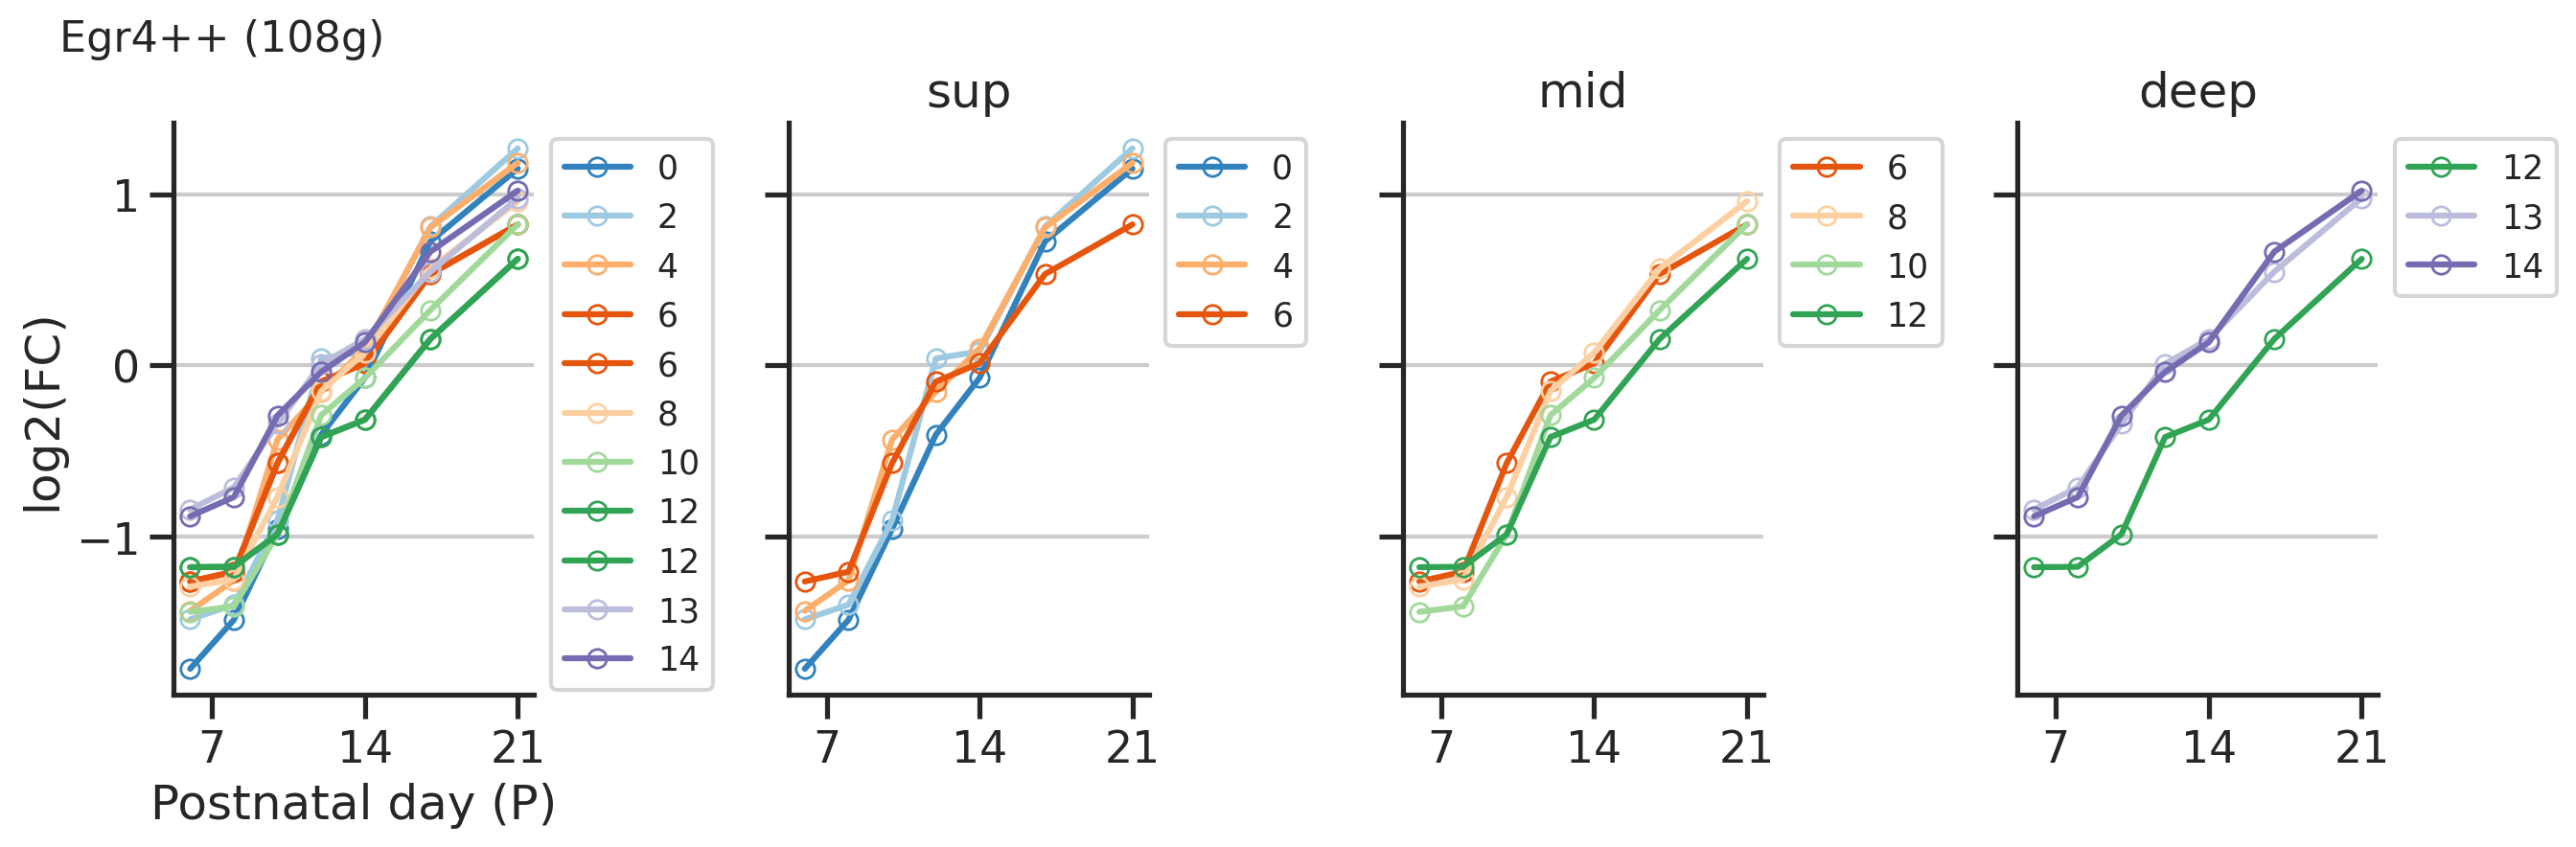

In [21]:
for reg_name in arg_regulons:
    plot2(reg_name, df_scenic1, baseline_gexp)

In [ ]:
for reg_name in all_regulons:
    plot2(reg_name, df_scenic1, baseline_gexp)